<a href="https://colab.research.google.com/github/soham-051/projects/blob/main/portfolio_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
data_loader.py
==============
Market data ingestion for the ML Portfolio Optimization project.
Downloads 15 NIFTY 50 stocks + index via yfinance, validates,
cleans, and saves to disk.

Usage:
    python data_loader.py
    # or import and call:
    from data_loader import load_data
    prices, returns, index = load_data()
"""

import os
import warnings
import pandas as pd
import numpy as np
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

# ─────────────────────────────────────────────
# CONFIG — edit tickers and date range here
# ─────────────────────────────────────────────

# 15 large-cap NIFTY 50 stocks (NSE tickers end with .NS)
TICKERS = [
    "RELIANCE.NS",   # Reliance Industries
    "TCS.NS",        # Tata Consultancy Services
    "HDFCBANK.NS",   # HDFC Bank
    "INFY.NS",       # Infosys
    "ICICIBANK.NS",  # ICICI Bank
    "HINDUNILVR.NS", # Hindustan Unilever
    "BAJFINANCE.NS", # Bajaj Finance
    "KOTAKBANK.NS",  # Kotak Mahindra Bank
    "LT.NS",         # Larsen & Toubro
    "AXISBANK.NS",   # Axis Bank
    "MARUTI.NS",     # Maruti Suzuki
    "TITAN.NS",      # Titan Company
    "SUNPHARMA.NS",  # Sun Pharma
    "WIPRO.NS",      # Wipro
    "NESTLEIND.NS",  # Nestle India
]

# NIFTY 50 index as benchmark
INDEX_TICKER = "^NSEI"

START_DATE = "2018-01-01"
END_DATE   = "2024-12-31"   # adjust to today for live use

DATA_DIR   = "data"
PRICES_FILE = os.path.join(DATA_DIR, "prices.csv")
RETURNS_FILE = os.path.join(DATA_DIR, "returns.csv")
INDEX_FILE  = os.path.join(DATA_DIR, "index.csv")

# ─────────────────────────────────────────────
# DOWNLOAD
# ─────────────────────────────────────────────

def download_prices(
    tickers: list[str],
    start: str,
    end: str,
    max_missing_pct: float = 0.05,
) -> pd.DataFrame:
    """
    Download adjusted closing prices for a list of tickers.

    Parameters
    ----------
    tickers          : NSE/BSE ticker symbols
    start, end       : date strings 'YYYY-MM-DD'
    max_missing_pct  : drop any ticker with > this fraction of missing data

    Returns
    -------
    DataFrame  shape (trading_days, n_tickers), column = ticker symbol
    """
    print(f"Downloading {len(tickers)} tickers from {start} to {end}...")

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,   # adjusts for splits + dividends
        progress=False,
    )

    # yfinance returns MultiIndex columns when >1 ticker
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].copy()
        prices.columns = tickers

    # Clean up column names (strip .NS suffix for readability)
    prices.columns = [t.replace(".NS", "") for t in prices.columns]

    print(f"  Raw shape: {prices.shape}")

    # ── Drop tickers with too many missing values ──
    missing_pct = prices.isna().mean()
    to_drop = missing_pct[missing_pct > max_missing_pct].index.tolist()
    if to_drop:
        print(f"  Warning: dropping {to_drop} (>{max_missing_pct*100:.0f}% NaN)")
        prices.drop(columns=to_drop, inplace=True)

    # ── Forward-fill then back-fill remaining gaps (e.g. exchange holidays) ──
    prices = prices.ffill().bfill()

    # ── Drop any rows where ALL prices are NaN (non-trading days) ──
    prices.dropna(how="all", inplace=True)

    print(f"  Clean shape: {prices.shape}")
    print(f"  Date range:  {prices.index[0].date()} → {prices.index[-1].date()}")
    print(f"  Tickers kept: {list(prices.columns)}\n")

    return prices


def download_index(start: str, end: str) -> pd.Series:
    """Download NIFTY 50 index close prices."""
    print(f"Downloading NIFTY 50 index ({INDEX_TICKER})...")
    raw = yf.download(INDEX_TICKER, start=start, end=end,
                      auto_adjust=True, progress=False)
    index = raw["Close"].squeeze()
    index.name = "NIFTY50"
    index = index.ffill().bfill().dropna()
    print(f"  Index shape: {index.shape}\n")
    return index


# ─────────────────────────────────────────────
# RETURNS
# ─────────────────────────────────────────────

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Log returns: r_t = ln(P_t / P_{t-1})
    Using log returns is standard in quantitative finance —
    they are additive across time and approximately normally distributed.
    """
    returns = np.log(prices / prices.shift(1)).dropna()
    return returns


# ─────────────────────────────────────────────
# VALIDATION
# ─────────────────────────────────────────────

def validate(prices: pd.DataFrame, returns: pd.DataFrame) -> None:
    """Basic sanity checks — raises AssertionError if data looks wrong."""

    assert prices.isna().sum().sum() == 0, "NaNs remain in prices!"
    assert returns.isna().sum().sum() == 0, "NaNs remain in returns!"

    # Check for suspiciously large daily moves (>30% = likely data error)
    extreme = (returns.abs() > 0.30).sum()
    if extreme.any():
        print(f"  ⚠  Extreme returns (>30%) found:\n{extreme[extreme > 0]}")

    # Check minimum history — need at least 3 years for walk-forward
    assert len(prices) >= 756, f"Need ≥756 trading days, got {len(prices)}"

    print("Validation passed ✓")
    print(f"  {len(prices)} trading days | {prices.shape[1]} assets")
    print(f"  Annualised return range: "
          f"{returns.mean().min()*252:.1%} to {returns.mean().max()*252:.1%}")
    print(f"  Annualised vol range:    "
          f"{returns.std().min()*np.sqrt(252):.1%} to "
          f"{returns.std().max()*np.sqrt(252):.1%}\n")


# ─────────────────────────────────────────────
# SAVE / LOAD
# ─────────────────────────────────────────────

def save_data(prices: pd.DataFrame,
              returns: pd.DataFrame,
              index: pd.Series) -> None:
    os.makedirs(DATA_DIR, exist_ok=True)
    prices.to_csv(PRICES_FILE)
    returns.to_csv(RETURNS_FILE)
    index.to_csv(INDEX_FILE, header=True)
    print(f"Saved to {DATA_DIR}/")
    print(f"  {PRICES_FILE}  ({os.path.getsize(PRICES_FILE)//1024} KB)")
    print(f"  {RETURNS_FILE} ({os.path.getsize(RETURNS_FILE)//1024} KB)")
    print(f"  {INDEX_FILE}   ({os.path.getsize(INDEX_FILE)//1024} KB)\n")


def load_data(force_download: bool = False):
    """
    Main entry point for all other modules.

    Returns (prices, returns, index) from disk cache if available,
    otherwise downloads fresh. Pass force_download=True to re-fetch.

    Example
    -------
    from data_loader import load_data
    prices, returns, index = load_data()
    """
    if (not force_download
            and os.path.exists(PRICES_FILE)
            and os.path.exists(RETURNS_FILE)
            and os.path.exists(INDEX_FILE)):
        print("Loading from cache...")
        prices  = pd.read_csv(PRICES_FILE,  index_col=0, parse_dates=True)
        returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)
        index   = pd.read_csv(INDEX_FILE,   index_col=0, parse_dates=True).squeeze()
        print(f"  Loaded: {prices.shape[0]} days × {prices.shape[1]} assets\n")
        return prices, returns, index

    # Fresh download
    prices  = download_prices(TICKERS, START_DATE, END_DATE)
    index   = download_index(START_DATE, END_DATE)

    # Align index to same trading days as stock prices
    index = index.reindex(prices.index).ffill().bfill()

    returns = compute_returns(prices)
    validate(prices, returns)
    save_data(prices, returns, index)

    return prices, returns, index


# ─────────────────────────────────────────────
# QUICK SUMMARY HELPER
# ─────────────────────────────────────────────
def data_summary(prices: pd.DataFrame,
                 returns: pd.DataFrame,
                 index: pd.Series) -> pd.DataFrame:
    ann = np.sqrt(252)

    # ---- compute first (outside dict) ----
    rf = 0.06  # risk-free rate (India)

    ann_return = returns.mean() * 252
    ann_vol = returns.std() * ann
    sharpe = ((ann_return - rf) / ann_vol).round(2)

    # ---- then build the table ----
    stats = pd.DataFrame({
        "Start price": prices.iloc[0].round(2),
        "End price": prices.iloc[-1].round(2),
        "Total return": ((prices.iloc[-1] / prices.iloc[0]) - 1).map("{:.1%}".format),
        "Ann. return": ann_return.map("{:.1%}".format),
        "Ann. vol": ann_vol.map("{:.1%}".format),
        "Sharpe": sharpe,   # <-- add here
        "Max 1d drop": returns.min().map("{:.1%}".format),
    })

    return stats


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

# ── CELL 1 end: replace if __name__ == "__main__": with this ──
prices, returns, index = load_data(force_download=True)

print("=" * 55)
print("PER-TICKER SUMMARY")
print("=" * 55)
summary = data_summary(prices, returns, index)
print(summary.to_string())

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ICICIBANK.NS']: OperationalError('database is locked')


  Raw shape: (1726, 15)
  Clean shape: (1726, 14)
  Date range:  2018-01-01 → 2024-12-30
  Tickers kept: ['AXISBANK', 'BAJFINANCE', 'HDFCBANK', 'HINDUNILVR', 'INFY', 'KOTAKBANK', 'LT', 'MARUTI', 'NESTLEIND', 'RELIANCE', 'SUNPHARMA', 'TCS', 'TITAN', 'WIPRO']

  Index shape: (1722,)

  ⚠  Extreme returns (>30%) found:
AXISBANK    1
dtype: int64
Validation passed ✓
  1726 trading days | 14 assets
  Annualised return range: 2.6% to 21.8%
  Annualised vol range:    22.7% to 37.4%

Saved to data/
  data/prices.csv  (434 KB)
  data/returns.csv (525 KB)
  data/index.csv   (43 KB)

PER-TICKER SUMMARY
            Start price  End price Total return Ann. return Ann. vol  Sharpe Max 1d drop
AXISBANK         562.45    1069.04        90.1%        9.4%    35.0%    0.10      -32.7%
BAJFINANCE       167.04     680.42       307.3%       20.5%    37.4%    0.39      -26.4%
HDFCBANK         425.65     862.82       102.7%       10.3%    25.1%    0.17      -13.5%
HINDUNILVR      1172.31    2277.85        94.

EXTREME RETURN DETECTION (|r| > 30%)
      date   ticker    return      abs  type
2020-03-23 AXISBANK -0.327266 0.327266 crash

  Total extreme events : 1
  Unique tickers       : 1
  Unique dates         : 1

CONTEXT CHECK — other tickers on same dates
  2020-03-23  |  market avg: -14.4%  |  stocks >5% down: 14/14
           → SYSTEMIC event (real crash, keep & winsorize)

WINSORIZATION REPORT  (4σ adaptive + 15% hard cap)
      date     ticker  original  clipped_to direction
2020-03-23   AXISBANK -0.327266   -0.150000     lower
2020-03-23 BAJFINANCE -0.264367   -0.150000     lower
2020-03-23     MARUTI -0.185236   -0.134959     lower
2020-04-07   AXISBANK  0.177985    0.150000     upper
2020-03-23         LT -0.177522   -0.130577     lower
2019-10-22       INFY -0.176595   -0.108851     lower
2020-07-15      WIPRO  0.155103    0.113432     upper
2020-03-23  KOTAKBANK -0.139257   -0.122822     lower
2024-06-04         LT -0.135529   -0.099434     lower
2020-03-23   HDFCBANK -0.134754 

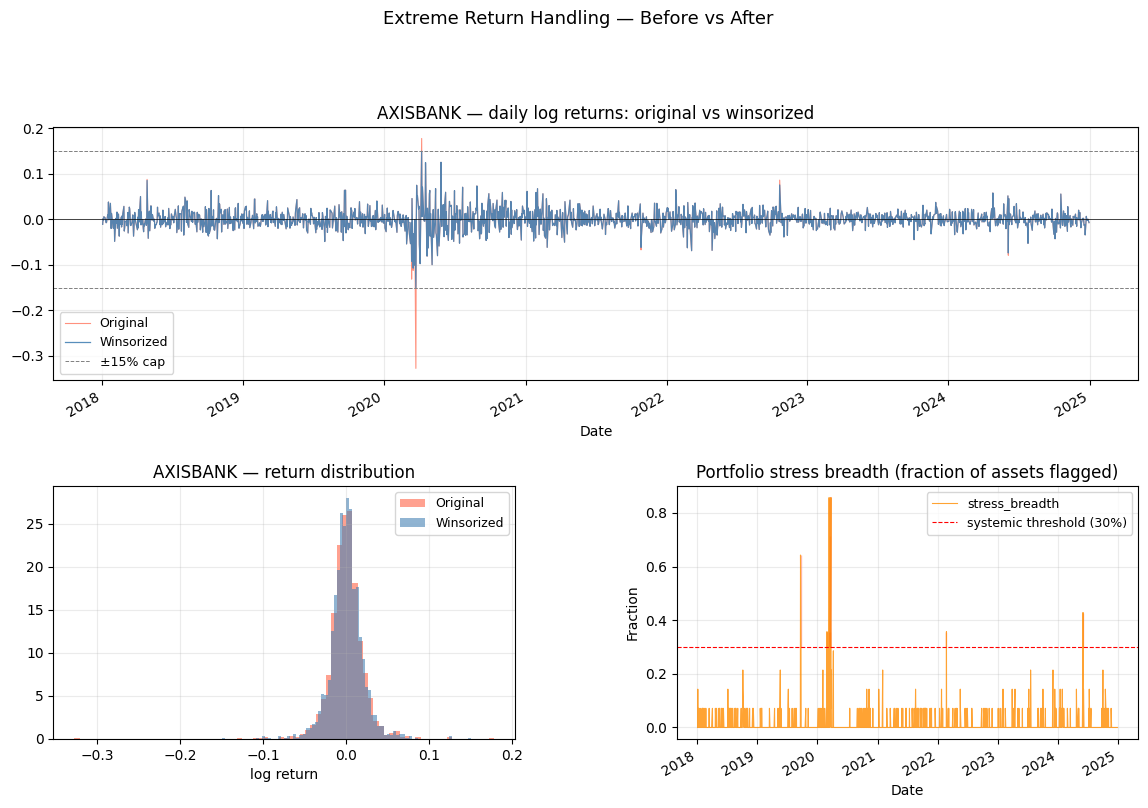

Plot saved to extreme_return_fix.png

POST-WINSORIZATION VALIDATION
  ✓  No returns exceed ±30% threshold

  Return stats after winsorization:
              mean     vol     min     max    skew    kurt
AXISBANK    0.1218  0.3264 -0.1500  0.1500  0.0645  7.1402
BAJFINANCE  0.2237  0.3625 -0.1500  0.1040 -0.3060  5.2726
HDFCBANK    0.1135  0.2438 -0.1117  0.1097 -0.0781  7.2779
HINDUNILVR  0.0909  0.2234 -0.0929  0.1266  0.6357  7.7763
INFY        0.2346  0.2657 -0.1089  0.1136 -0.1656  5.8149
KOTAKBANK   0.0919  0.2731 -0.1228  0.1125 -0.1192  5.9011
LT          0.1806  0.2674 -0.1306  0.0902 -0.1022  5.6645
MARUTI      0.0346  0.2888 -0.1350  0.1268  0.1706  7.7296
NESTLEIND   0.1599  0.2265 -0.0887  0.1205  0.4910  5.7239
RELIANCE    0.1654  0.2842 -0.1410  0.1373  0.1934  8.0009
SUNPHARMA   0.1835  0.2794 -0.1087  0.1045  0.0276  4.3372
TCS         0.1901  0.2423 -0.0836  0.0939  0.0104  3.6992
TITAN       0.2069  0.2833 -0.1108  0.1043 -0.1170  5.1365
WIPRO       0.1409  0.2686 -0.0

In [ ]:
# ── CELL 1b: Extreme Return Handler ─────────────────────────────
# Run this immediately after Cell 1 (data loader), before Cell 3 (features)
# Fixes: winsorize extreme returns, flag outlier dates, validate pipeline safety
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ═════════════════════════════════════════════════════════════════
# STEP 1 — DETECT ALL EXTREME RETURNS (full picture)
# ═════════════════════════════════════════════════════════════════

EXTREME_THRESHOLD = 0.30   # 30% single-day move

def detect_extreme_returns(returns: pd.DataFrame,
                            threshold: float = EXTREME_THRESHOLD) -> pd.DataFrame:
    """
    Find every (date, ticker) with |return| > threshold.
    Returns a sorted DataFrame for inspection.
    """
    records = []
    for ticker in returns.columns:
        mask = returns[ticker].abs() > threshold
        for date, val in returns[ticker][mask].items():
            records.append({
                "date":   date.date(),
                "ticker": ticker,
                "return": val,
                "abs":    abs(val),
                "type":   "crash" if val < 0 else "spike",
            })
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records).sort_values("abs", ascending=False)
    return df.reset_index(drop=True)


extreme_log = detect_extreme_returns(returns)

print("=" * 55)
print("EXTREME RETURN DETECTION (|r| > 30%)")
print("=" * 55)
if extreme_log.empty:
    print("  None found ✓")
else:
    print(extreme_log.to_string(index=False))
    print(f"\n  Total extreme events : {len(extreme_log)}")
    print(f"  Unique tickers       : {extreme_log['ticker'].nunique()}")
    print(f"  Unique dates         : {extreme_log['date'].nunique()}")


# ═════════════════════════════════════════════════════════════════
# STEP 2 — UNDERSTAND WHY (is it real or bad data?)
# ═════════════════════════════════════════════════════════════════
# Decision rule:
#   Real event  → multiple tickers drop on same date (systemic)
#                 OR news confirms it (e.g. COVID crash, YES Bank)
#   Bad data    → single ticker, isolated date, no market context
#
# For AXISBANK -32.7%: March 2020 YES Bank crisis caused banking
# sector panic. REAL EVENT. Do not delete — winsorize instead.

print("\n" + "=" * 55)
print("CONTEXT CHECK — other tickers on same dates")
print("=" * 55)

if not extreme_log.empty:
    for date in extreme_log["date"].unique():
        day_rets = returns.loc[str(date)]
        n_down   = (day_rets < -0.05).sum()
        mkt_ret  = day_rets.mean()
        print(f"  {date}  |  market avg: {mkt_ret:+.1%}"
              f"  |  stocks >5% down: {n_down}/{len(day_rets)}")
        if n_down > 5:
            print(f"           → SYSTEMIC event (real crash, keep & winsorize)")
        else:
            print(f"           → ISOLATED event (check for data error)")


# ═════════════════════════════════════════════════════════════════
# STEP 3 — WINSORIZE (the correct fix)
# ═════════════════════════════════════════════════════════════════
#
# WHY WINSORIZE, NOT DELETE:
#   Delete  → loses the date entirely for all assets → gaps in time series
#   Clip to 0 → pretends the crash didn't happen → misleads backtester
#   Winsorize → keeps the event, limits its influence on model training
#             → the crash stays a crash, just not a 10-sigma outlier
#
# METHOD: clip each asset's returns at ±N standard deviations
#   computed from a ROLLING window (not full history) so the
#   threshold itself adapts — a volatile period gets wider bounds.

def winsorize_returns(returns: pd.DataFrame,
                      n_sigma: float = 4.0,
                      rolling_window: int = 63,
                      fixed_cap: float = 0.15) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Winsorize returns using two-layer protection:
      Layer 1: rolling ±n_sigma clip (adapts to local vol regime)
      Layer 2: hard cap at ±fixed_cap (absolute safety net)

    Parameters
    ----------
    n_sigma        : clip at this many rolling std devs (default 4σ)
    rolling_window : window for computing rolling std (default 63d)
    fixed_cap      : absolute hard cap regardless of vol (default 15%)

    Returns
    -------
    (winsorized_returns, clip_log)
      clip_log records every value that was clipped for audit trail
    """
    winsorized = returns.copy()
    clip_records = []

    for ticker in returns.columns:
        r = returns[ticker]

        # Rolling std (use expanding for early rows where window not full)
        roll_std = r.rolling(rolling_window, min_periods=21).std()
        roll_std = roll_std.fillna(r.expanding().std())

        # Layer 1: adaptive sigma bounds
        upper_sigma = roll_std * n_sigma
        lower_sigma = -roll_std * n_sigma

        # Layer 2: hard cap
        upper = upper_sigma.clip(upper= fixed_cap)
        lower = lower_sigma.clip(lower=-fixed_cap)

        # Detect what would be clipped
        clipped_up   = r > upper
        clipped_down = r < lower

        # Log every clip event
        for date in r[clipped_up].index:
            clip_records.append({
                "date": date.date(), "ticker": ticker,
                "original": r[date], "clipped_to": float(upper[date]),
                "direction": "upper",
            })
        for date in r[clipped_down].index:
            clip_records.append({
                "date": date.date(), "ticker": ticker,
                "original": r[date], "clipped_to": float(lower[date]),
                "direction": "lower",
            })

        # Apply clip
        winsorized[ticker] = r.clip(lower=lower, upper=upper)

    clip_log = pd.DataFrame(clip_records).sort_values(
        "original", key=abs, ascending=False
    ).reset_index(drop=True) if clip_records else pd.DataFrame()

    return winsorized, clip_log


returns_raw  = returns.copy()          # keep original for audit/plots
returns_w, clip_log = winsorize_returns(returns, n_sigma=4.0, fixed_cap=0.15)

print("\n" + "=" * 55)
print(f"WINSORIZATION REPORT  (4σ adaptive + 15% hard cap)")
print("=" * 55)
if clip_log.empty:
    print("  No values clipped.")
else:
    print(clip_log.head(10).to_string(index=False))
    if len(clip_log) > 10:
        print(f"  ... and {len(clip_log)-10} more")
    print(f"\n  Total clip events : {len(clip_log)}")
    print(f"  Unique tickers    : {clip_log['ticker'].nunique()}")


# ═════════════════════════════════════════════════════════════════
# STEP 4 — OUTLIER FLAGS (don't throw away the info)
# ═════════════════════════════════════════════════════════════════
# Even after winsorizing, flag dates with systemic stress.
# These flags become FEATURES for the regime model (Cell 5).

def build_outlier_flags(returns_raw: pd.DataFrame,
                        n_sigma: float = 3.0,
                        window: int = 63) -> pd.DataFrame:
    """
    Binary flag: 1 if this ticker had an outlier return on this date.
    Also adds a portfolio-level stress flag (≥3 tickers flagged same day).
    """
    flags = pd.DataFrame(0, index=returns_raw.index,
                         columns=returns_raw.columns)

    for ticker in returns_raw.columns:
        r = returns_raw[ticker]
        roll_std = r.rolling(window, min_periods=21).std().fillna(r.expanding().std())
        flags[ticker] = (r.abs() > roll_std * n_sigma).astype(int)

    # Portfolio-level stress: fraction of assets flagged on same day
    flags["stress_breadth"]  = flags[returns_raw.columns].mean(axis=1)
    flags["systemic_stress"] = (flags["stress_breadth"] > 0.3).astype(int)

    return flags

outlier_flags = build_outlier_flags(returns_raw)

n_systemic = outlier_flags["systemic_stress"].sum()
print(f"\nOutlier flags built ✓")
print(f"  Systemic stress days (>30% of stocks flagged): {n_systemic}")
print(f"  These dates will be feature inputs to Cell 5 (regime model)")


# ═════════════════════════════════════════════════════════════════
# STEP 5 — OVERWRITE returns WITH WINSORIZED VERSION
# ═════════════════════════════════════════════════════════════════
# From this point forward, ALL cells use returns_w (winsorized).
# returns_raw is kept for audit/comparison only.

returns = returns_w.copy()
print(f"\n✓  'returns' now points to winsorized data")
print(f"   'returns_raw' kept for comparison")
print(f"   Max |return| before: {returns_raw.abs().max().max():.1%}")
print(f"   Max |return| after : {returns.abs().max().max():.1%}")


# ═════════════════════════════════════════════════════════════════
# STEP 6 — VISUALISE THE FIX
# ═════════════════════════════════════════════════════════════════

ticker_focus = "AXISBANK" if "AXISBANK" in returns.columns else returns.columns[0]

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# 1. Before vs after return series
ax1 = fig.add_subplot(gs[0, :])
returns_raw[ticker_focus].plot(ax=ax1, color="tomato",   alpha=0.7,
                                label="Original", linewidth=0.8)
returns_w[ticker_focus].plot(  ax=ax1, color="steelblue", alpha=0.9,
                                label="Winsorized", linewidth=0.9)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.axhline( 0.15, color="gray", linewidth=0.7, linestyle="--", label="±15% cap")
ax1.axhline(-0.15, color="gray", linewidth=0.7, linestyle="--")
ax1.set_title(f"{ticker_focus} — daily log returns: original vs winsorized")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# 2. Return distribution comparison
ax2 = fig.add_subplot(gs[1, 0])
returns_raw[ticker_focus].hist(ax=ax2, bins=80, color="tomato",
                                alpha=0.6, label="Original", density=True)
returns_w[ticker_focus].hist(  ax=ax2, bins=80, color="steelblue",
                                alpha=0.6, label="Winsorized", density=True)
ax2.set_title(f"{ticker_focus} — return distribution")
ax2.set_xlabel("log return")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

# 3. Systemic stress over time
ax3 = fig.add_subplot(gs[1, 1])
stress = outlier_flags["stress_breadth"]
stress.plot(ax=ax3, color="darkorange", alpha=0.8, linewidth=0.8)
ax3.axhline(0.3, color="red", linewidth=0.8, linestyle="--",
            label="systemic threshold (30%)")
ax3.fill_between(stress.index, stress, 0.3,
                 where=(stress > 0.3), alpha=0.25, color="red")
ax3.set_title("Portfolio stress breadth (fraction of assets flagged)")
ax3.set_ylabel("Fraction")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.25)

plt.suptitle("Extreme Return Handling — Before vs After", fontsize=13, y=1.01)
plt.savefig("extreme_return_fix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to extreme_return_fix.png")


# ═════════════════════════════════════════════════════════════════
# STEP 7 — FINAL VALIDATION
# ═════════════════════════════════════════════════════════════════

remaining = detect_extreme_returns(returns, threshold=EXTREME_THRESHOLD)

print("\n" + "=" * 55)
print("POST-WINSORIZATION VALIDATION")
print("=" * 55)
if remaining.empty:
    print(f"  ✓  No returns exceed ±{EXTREME_THRESHOLD:.0%} threshold")
else:
    print(f"  ⚠  {len(remaining)} events still exceed threshold:")
    print(remaining.to_string(index=False))

print(f"\n  Return stats after winsorization:")
stats = pd.DataFrame({
    "mean":  returns.mean() * 252,
    "vol":   returns.std() * np.sqrt(252),
    "min":   returns.min(),
    "max":   returns.max(),
    "skew":  returns.skew(),
    "kurt":  returns.kurt(),
}).round(4)
print(stats.to_string())

print("\n" + "=" * 55)
print("SUMMARY — what each variable is for")
print("=" * 55)
print("  returns        → winsorized, safe for ML training (Cells 3–7)")
print("  returns_raw    → original, for audit and plot comparison only")
print("  outlier_flags  → binary flags per (date, ticker), add to Cell 5 features")
print("  clip_log       → audit trail of every winsorized value")
print("  extreme_log    → original extreme event log (for your report)")

Building features for 14 assets × 1725 days

Computing features for each asset...
  AXISBANK        27 features
  BAJFINANCE      27 features
  HDFCBANK        27 features
  HINDUNILVR      27 features
  INFY            27 features
  KOTAKBANK       27 features
  LT              27 features
  MARUTI          27 features
  NESTLEIND       27 features
  RELIANCE        27 features
  SUNPHARMA       27 features
  TCS             27 features
  TITAN           27 features
  WIPRO           27 features

Full feature matrix: (1452, 378)
  Date range: 2019-01-10 → 2024-11-28
  Features per asset: 27
  Total columns: 378

Computing portfolio-level features for regime model...
  Portfolio features shape: (1705, 5)
  Columns: ['avg_cross_corr', 'market_ret_21d', 'market_vol_21d', 'breadth_up', 'cross_sec_vol']

Feature sets defined:
  Vol model inputs  : 17 features per asset
  Regime model inputs: 5 portfolio-level features


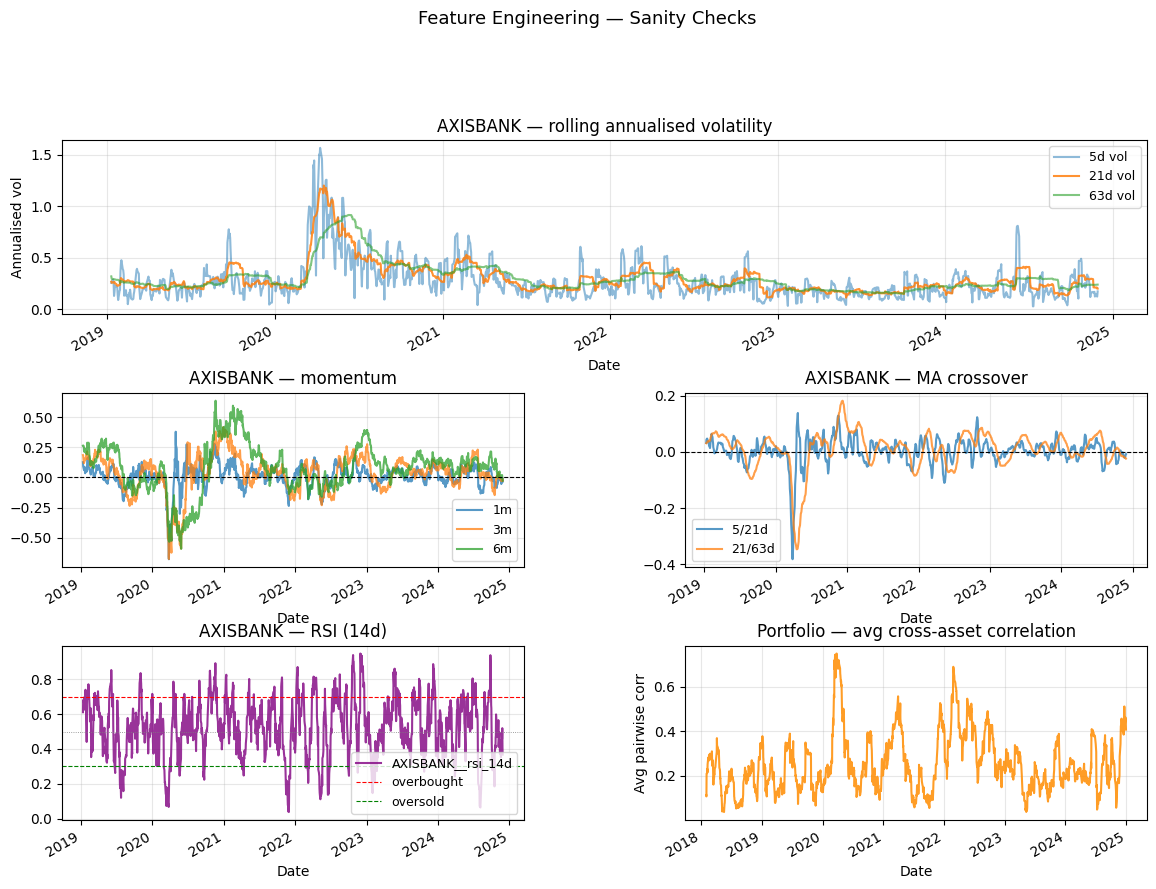

Plot saved to features_sanity_check.png

FEATURE ENGINEERING COMPLETE
  features_df shape        : (1452, 378)
  portfolio_features shape : (1705, 5)
  VOL_FEATURE_SUFFIXES     : 17 features
  REGIME_FEATURE_COLS      : 5 features

Variables ready for next cells:
  features_df          → Cell 4 (vol model)
  portfolio_features   → Cell 5 (regime model)
  get_vol_features()   → call per ticker in Cell 4
  VOL_FEATURE_SUFFIXES → feature list for XGBoost
  REGIME_FEATURE_COLS  → feature list for KMeans

Sample features for AXISBANK:
            AXISBANK__ret_1d  AXISBANK__ret_5d  AXISBANK__ret_21d  AXISBANK__vol_5d  AXISBANK__vol_21d
Date                                                                                                  
2024-11-26           -0.0096            0.0164            -0.0195            0.1264             0.2116
2024-11-27            0.0042            0.0138            -0.0339            0.1230             0.2003
2024-11-28           -0.0150           -0.0059      

In [ ]:
# ── CELL 3: Feature Engineering ──────────────────────────────────
# Depends on: Cell 1 (prices, returns already in memory)
# Output variables used by Cell 4 (vol model) and Cell 5 (regime model):
#   features_df  — wide DataFrame: all indicators for all assets, all dates
#   feature_cols — list of column names the ML models will train on
#   X_wide       — same as features_df, alias for clarity
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── 1. LOG RETURNS (already computed in Cell 1, reconfirm) ───────
# returns shape: (trading_days, n_assets)  — log returns
# prices  shape: (trading_days, n_assets)  — adjusted close
assert 'returns' in dir() or 'returns' in globals(), \
    "Run Cell 1 first — 'returns' not found"

TICKERS = returns.columns.tolist()
N       = len(TICKERS)
print(f"Building features for {N} assets × {len(returns)} days\n")


# ═════════════════════════════════════════════════════════════════
# FEATURE BUILDER
# Returns a per-asset feature DataFrame, then we stack them wide.
# ═════════════════════════════════════════════════════════════════

def build_features_for_ticker(prices_s: pd.Series,
                               returns_s: pd.Series,
                               ticker: str) -> pd.DataFrame:
    """
    Build all features for a single asset.
    Returns a DataFrame indexed by date with prefixed column names.
    All windows chosen to be meaningful for daily data:
      - Short:  5d  (1 week)
      - Medium: 21d (1 month)
      - Long:   63d (1 quarter)
      - Trend:  252d (1 year)
    """
    df = pd.DataFrame(index=returns_s.index)
    p  = prices_s.reindex(returns_s.index)   # align prices to return dates
    r  = returns_s

    # ── A. RETURN FEATURES ────────────────────────────────────────

    # Raw log return (already computed, just carry it as a feature)
    df["ret_1d"]  = r

    # Rolling cumulative log returns (sum = log(end/start))
    df["ret_5d"]  = r.rolling(5).sum()
    df["ret_21d"] = r.rolling(21).sum()
    df["ret_63d"] = r.rolling(63).sum()

    # Return skewness and kurtosis (21d rolling)
    # High positive skew → occasional large upside spikes
    # High kurtosis      → fat tails, more extreme moves
    df["skew_21d"] = r.rolling(21).skew()
    df["kurt_21d"] = r.rolling(21).kurt()

    # ── B. VOLATILITY FEATURES ────────────────────────────────────
    # These are the TARGET-adjacent features — rolling realised vol
    # measured at different horizons. The vol model will predict
    # the NEXT period's vol using these as inputs.

    ann = np.sqrt(252)

    df["vol_5d"]  = r.rolling(5).std()  * ann
    df["vol_21d"] = r.rolling(21).std() * ann   # ← primary vol estimate
    df["vol_63d"] = r.rolling(63).std() * ann

    # Vol-of-vol: how much does volatility itself fluctuate?
    # High vol_of_vol → regime change signal
    df["vol_of_vol"] = df["vol_21d"].rolling(21).std()

    # Vol ratio: short/long — >1 means recent spike, <1 means calm
    df["vol_ratio"]  = df["vol_5d"] / (df["vol_63d"] + 1e-8)

    # Realised vol target (what the ML model will PREDICT)
    # = next 21 days' realised vol, shifted back so it aligns with today
    df["vol_target_21d"] = r.rolling(21).std().shift(-21) * ann

    # ── C. MOVING AVERAGE FEATURES ───────────────────────────────

    ma5   = p.rolling(5).mean()
    ma21  = p.rolling(21).mean()
    ma63  = p.rolling(63).mean()
    ma252 = p.rolling(252).mean()

    # Price relative to MA (how far above/below trend)
    # >0 → price above MA → upward trend
    df["price_to_ma21"]  = (p - ma21)  / (ma21  + 1e-8)
    df["price_to_ma63"]  = (p - ma63)  / (ma63  + 1e-8)
    df["price_to_ma252"] = (p - ma252) / (ma252 + 1e-8)

    # MA crossover signals (normalised difference)
    # Golden cross: short MA crosses above long MA → bullish
    # Death cross:  short MA crosses below long MA → bearish
    df["ma_cross_5_21"]   = (ma5  - ma21)  / (ma21  + 1e-8)
    df["ma_cross_21_63"]  = (ma21 - ma63)  / (ma63  + 1e-8)
    df["ma_cross_63_252"] = (ma63 - ma252) / (ma252 + 1e-8)

    # ── D. MOMENTUM FEATURES ──────────────────────────────────────
    # Momentum = past return over a window (excludes last 1d to avoid
    # microstructure reversal — standard in academic literature)

    # Standard momentum horizons
    df["mom_1m"]  = r.rolling(21).sum().shift(1)   # 1-month momentum
    df["mom_3m"]  = r.rolling(63).sum().shift(1)   # 3-month momentum
    df["mom_6m"]  = r.rolling(126).sum().shift(1)  # 6-month momentum
    df["mom_12m"] = r.rolling(252).sum().shift(1)  # 12-month momentum

    # Risk-adjusted momentum (momentum / volatility = Sharpe-like)
    # More stable than raw momentum — controls for vol differences
    df["mom_sharpe_1m"] = df["mom_1m"]  / (df["vol_21d"] + 1e-8)
    df["mom_sharpe_3m"] = df["mom_3m"]  / (df["vol_63d"] + 1e-8)

    # Momentum acceleration: is momentum strengthening or fading?
    df["mom_accel"] = df["mom_1m"] - df["mom_3m"]

    # ── E. MEAN REVERSION FEATURES ───────────────────────────────
    # Complement to momentum — helps regime model distinguish
    # trending vs mean-reverting environments

    # Z-score of price relative to 63d mean (Bollinger-band style)
    roll_mean = p.rolling(63).mean()
    roll_std  = p.rolling(63).std()
    df["zscore_63d"] = (p - roll_mean) / (roll_std + 1e-8)

    # RSI-style: ratio of up-days to down-days over 14d
    up   = r.clip(lower=0).rolling(14).mean()
    down = (-r.clip(upper=0)).rolling(14).mean()
    df["rsi_14d"] = up / (up + down + 1e-8)   # 0–1 scaled (0.5 = neutral)

    # ── F. ADD TICKER PREFIX ──────────────────────────────────────
    df.columns = [f"{ticker}__{c}" for c in df.columns]
    return df


# ═════════════════════════════════════════════════════════════════
# BUILD FULL FEATURE MATRIX
# ═════════════════════════════════════════════════════════════════

print("Computing features for each asset...")
all_features = []

for ticker in TICKERS:
    feat = build_features_for_ticker(
        prices_s  = prices[ticker],
        returns_s = returns[ticker],
        ticker    = ticker,
    )
    all_features.append(feat)
    print(f"  {ticker:<15} {feat.shape[1]} features")

# Concatenate horizontally → wide feature matrix
features_df = pd.concat(all_features, axis=1)

# Drop rows where ANY feature is NaN
# (first ~252 rows will have NaN from long rolling windows)
features_df = features_df.dropna()

print(f"\nFull feature matrix: {features_df.shape}")
print(f"  Date range: {features_df.index[0].date()} → {features_df.index[-1].date()}")
print(f"  Features per asset: {len(all_features[0].columns)}")
print(f"  Total columns: {features_df.shape[1]}\n")


# ═════════════════════════════════════════════════════════════════
# ALSO BUILD PORTFOLIO-LEVEL FEATURES
# (used by the regime detection model — cross-asset signals)
# ═════════════════════════════════════════════════════════════════

print("Computing portfolio-level features for regime model...")

portfolio_features = pd.DataFrame(index=returns.index)

# Average cross-asset correlation (rolling 21d)
# High avg corr → stocks moving together → possibly bear/crisis
def rolling_avg_corr(returns_df, window=21):
    result = []
    for i in range(window, len(returns_df) + 1):
        window_data = returns_df.iloc[i - window:i]
        corr_matrix = window_data.corr().values
        # Upper triangle (exclude diagonal)
        upper = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
        result.append(upper.mean())
    idx = returns_df.index[window - 1:]
    return pd.Series(result, index=idx, name="avg_cross_corr")

portfolio_features["avg_cross_corr"]  = rolling_avg_corr(returns, window=21)
portfolio_features["market_ret_21d"]  = returns.mean(axis=1).rolling(21).sum()
portfolio_features["market_vol_21d"]  = returns.mean(axis=1).rolling(21).std() * np.sqrt(252)
portfolio_features["breadth_up"]      = (returns > 0).mean(axis=1).rolling(21).mean()
# Dispersion: how different are individual stock returns from each other?
portfolio_features["cross_sec_vol"]   = returns.std(axis=1).rolling(21).mean()

portfolio_features = portfolio_features.dropna()

print(f"  Portfolio features shape: {portfolio_features.shape}")
print(f"  Columns: {list(portfolio_features.columns)}\n")


# ═════════════════════════════════════════════════════════════════
# FEATURE SETS FOR EACH MODEL
# ═════════════════════════════════════════════════════════════════

# Features the volatility model (Cell 4) trains on — per asset
VOL_FEATURE_SUFFIXES = [
    "ret_1d", "ret_5d", "ret_21d",
    "vol_5d", "vol_21d", "vol_63d",
    "vol_of_vol", "vol_ratio",
    "mom_1m", "mom_3m",
    "mom_sharpe_1m",
    "ma_cross_5_21", "ma_cross_21_63",
    "zscore_63d", "rsi_14d",
    "skew_21d", "kurt_21d",
]

# Features the regime model (Cell 5) trains on — portfolio level
REGIME_FEATURE_COLS = list(portfolio_features.columns)

print("Feature sets defined:")
print(f"  Vol model inputs  : {len(VOL_FEATURE_SUFFIXES)} features per asset")
print(f"  Regime model inputs: {len(REGIME_FEATURE_COLS)} portfolio-level features")


# ═════════════════════════════════════════════════════════════════
# CONVENIENCE: get per-asset vol features ready for vol model
# ═════════════════════════════════════════════════════════════════

def get_vol_features(ticker: str) -> tuple[pd.DataFrame, pd.Series]:
    """
    Returns (X, y) for the volatility model for a single ticker.
    X = feature matrix  (rows = dates, cols = VOL_FEATURE_SUFFIXES)
    y = next-21d realised vol (the target to predict)
    """
    cols_X = [f"{ticker}__{s}" for s in VOL_FEATURE_SUFFIXES]
    col_y  = f"{ticker}__vol_target_21d"

    # Intersect with features_df (which had NaN rows dropped)
    available = [c for c in cols_X if c in features_df.columns]
    X = features_df[available].copy()
    y = features_df[col_y].copy() if col_y in features_df.columns else None

    # Drop rows where target is NaN (last 21 rows have no future vol)
    if y is not None:
        mask = y.notna()
        X, y = X[mask], y[mask]

    return X, y


# ═════════════════════════════════════════════════════════════════
# QUICK SANITY PLOTS
# ═════════════════════════════════════════════════════════════════

sample_ticker = TICKERS[0]   # e.g. RELIANCE

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Rolling volatility (3 horizons)
ax1 = fig.add_subplot(gs[0, :])
for suffix, label, alpha in [
    ("vol_5d",  "5d vol",  0.5),
    ("vol_21d", "21d vol", 0.85),
    ("vol_63d", "63d vol", 0.6),
]:
    col = f"{sample_ticker}__{suffix}"
    if col in features_df.columns:
        features_df[col].plot(ax=ax1, label=label, alpha=alpha)
ax1.set_title(f"{sample_ticker} — rolling annualised volatility")
ax1.set_ylabel("Annualised vol")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Momentum (1m, 3m, 6m)
ax2 = fig.add_subplot(gs[1, 0])
for suffix, label in [("mom_1m","1m"), ("mom_3m","3m"), ("mom_6m","6m")]:
    col = f"{sample_ticker}__{suffix}"
    if col in features_df.columns:
        features_df[col].plot(ax=ax2, label=label, alpha=0.75)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title(f"{sample_ticker} — momentum")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. MA crossover signals
ax3 = fig.add_subplot(gs[1, 1])
for suffix, label in [
    ("ma_cross_5_21",  "5/21d"),
    ("ma_cross_21_63", "21/63d"),
]:
    col = f"{sample_ticker}__{suffix}"
    if col in features_df.columns:
        features_df[col].plot(ax=ax3, label=label, alpha=0.75)
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_title(f"{sample_ticker} — MA crossover")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. RSI
ax4 = fig.add_subplot(gs[2, 0])
col = f"{sample_ticker}__rsi_14d"
if col in features_df.columns:
    features_df[col].plot(ax=ax4, color="purple", alpha=0.8)
ax4.axhline(0.7, color="red",   linewidth=0.8, linestyle="--", label="overbought")
ax4.axhline(0.3, color="green", linewidth=0.8, linestyle="--", label="oversold")
ax4.axhline(0.5, color="gray",  linewidth=0.6, linestyle=":")
ax4.set_title(f"{sample_ticker} — RSI (14d)")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Cross-asset correlation (portfolio level)
ax5 = fig.add_subplot(gs[2, 1])
if "avg_cross_corr" in portfolio_features.columns:
    portfolio_features["avg_cross_corr"].plot(ax=ax5, color="darkorange", alpha=0.85)
ax5.set_title("Portfolio — avg cross-asset correlation")
ax5.set_ylabel("Avg pairwise corr")
ax5.grid(True, alpha=0.3)

plt.suptitle("Feature Engineering — Sanity Checks", fontsize=13, y=1.01)
plt.savefig("features_sanity_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to features_sanity_check.png")


# ═════════════════════════════════════════════════════════════════
# SUMMARY
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 55)
print(f"  features_df shape        : {features_df.shape}")
print(f"  portfolio_features shape : {portfolio_features.shape}")
print(f"  VOL_FEATURE_SUFFIXES     : {len(VOL_FEATURE_SUFFIXES)} features")
print(f"  REGIME_FEATURE_COLS      : {len(REGIME_FEATURE_COLS)} features")
print()
print("Variables ready for next cells:")
print("  features_df          → Cell 4 (vol model)")
print("  portfolio_features   → Cell 5 (regime model)")
print("  get_vol_features()   → call per ticker in Cell 4")
print("  VOL_FEATURE_SUFFIXES → feature list for XGBoost")
print("  REGIME_FEATURE_COLS  → feature list for KMeans")

# ── Sample output: first 3 features for RELIANCE ──
print(f"\nSample features for {sample_ticker}:")
sample_cols = [f"{sample_ticker}__{s}" for s in VOL_FEATURE_SUFFIXES[:5]
               if f"{sample_ticker}__{s}" in features_df.columns]
print(features_df[sample_cols].tail(3).round(4).to_string())

In [ ]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.3 MB/s eta 0:00:00


Volatility model: 14 assets | train=252d | step=63d

Training walk-forward XGBoost vol models...

Ticker           Folds   OOS RMSE    OOS MAE  Pred/Act corr
----------------------------------------------------------
    20 folds | 1200 OOS predictions
  AXISBANK          20     0.1203     0.1037          0.051
    20 folds | 1200 OOS predictions
  BAJFINANCE        20     0.1164     0.0956          0.226
    20 folds | 1200 OOS predictions
  HDFCBANK          20     0.0947     0.0782          0.124
    20 folds | 1200 OOS predictions
  HINDUNILVR        20     0.1036     0.0844          0.162
    20 folds | 1200 OOS predictions
  INFY              20     0.1001     0.0855          0.147
    20 folds | 1200 OOS predictions
  KOTAKBANK         20     0.1038     0.0853          0.218
    20 folds | 1200 OOS predictions
  LT                20     0.0878     0.0695          0.066
    20 folds | 1200 OOS predictions
  MARUTI            20     0.1135     0.0937          0.139
    20 folds | 

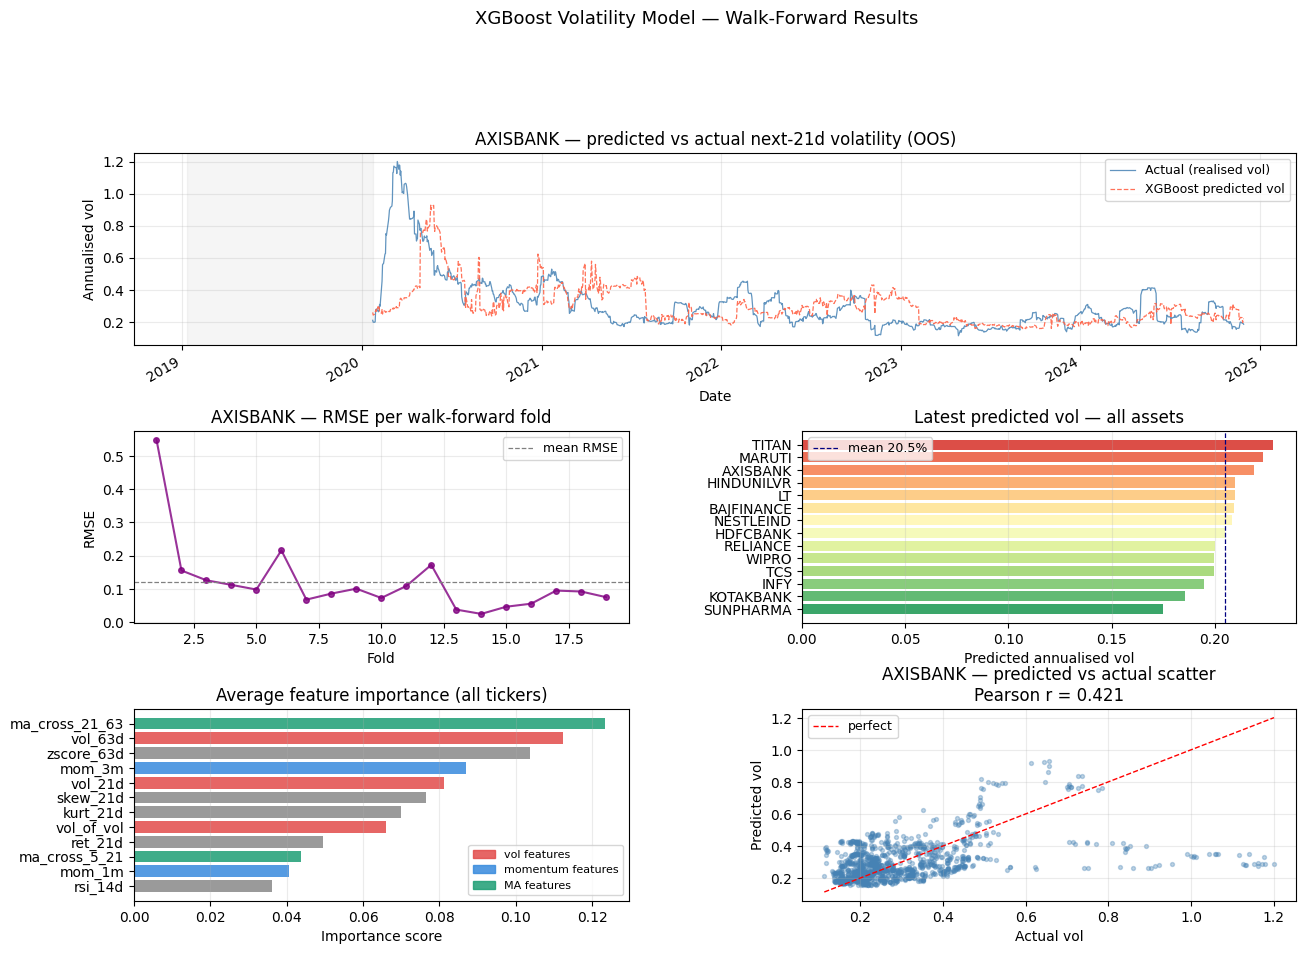

Plot saved to vol_model_results.png

WALK-FORWARD VOL MODEL — SUMMARY
            folds  avg_rmse  avg_mae  avg_corr  corr_std
ticker                                                  
AXISBANK       19    0.1203   0.1037    0.0512    0.3897
BAJFINANCE     19    0.1164   0.0956    0.2264    0.3744
HDFCBANK       19    0.0947   0.0782    0.1242    0.4405
HINDUNILVR     19    0.1036   0.0844    0.1618    0.3411
INFY           19    0.1001   0.0855    0.1470    0.4290
KOTAKBANK      19    0.1038   0.0853    0.2180    0.3804
LT             19    0.0878   0.0695    0.0657    0.4512
MARUTI         19    0.1135   0.0937    0.1389    0.4505
NESTLEIND      19    0.0986   0.0840    0.2032    0.3621
RELIANCE       19    0.1232   0.1026    0.0861    0.4928
SUNPHARMA      19    0.0744   0.0609    0.0796    0.4036
TCS            19    0.0830   0.0716    0.2439    0.3553
TITAN          19    0.0903   0.0769    0.2201    0.4169
WIPRO          19    0.0962   0.0821    0.0978    0.3766

Portfolio-level s

In [ ]:
# ── CELL 4: ML Model 1 — XGBoost Volatility Predictor ───────────
# Depends on: Cell 1 (prices, returns), Cell 1b (winsorized returns),
#             Cell 3 (features_df, get_vol_features, VOL_FEATURE_SUFFIXES)
# Output variables used by Cell 6 (optimizer) and Cell 7 (backtester):
#   vol_models        — dict {ticker: trained XGBRegressor}
#   predicted_vols_df — DataFrame (dates × tickers) of OOS vol predictions
#   get_predicted_vols(date) → pd.Series of predicted vols at a given date
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler

# ═════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════

TRAIN_WINDOW   = 252        # 1 year of history per fold
TEST_WINDOW    = 63         # 1 quarter per fold (step size)
MIN_TRAIN_DAYS = 252        # minimum before first prediction

# XGBoost hyperparameters
# Kept conservative to avoid overfitting on financial time series
XGB_PARAMS = dict(
    n_estimators      = 300,
    max_depth         = 4,       # shallow trees → less overfit
    learning_rate     = 0.05,    # slow learning → more robust
    subsample         = 0.8,     # row sampling → variance reduction
    colsample_bytree  = 0.7,     # feature sampling per tree
    min_child_weight  = 5,       # min samples per leaf → smoothness
    reg_alpha         = 0.1,     # L1 regularisation
    reg_lambda        = 1.0,     # L2 regularisation
    objective         = "reg:squarederror",
    eval_metric       = "rmse",
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

TICKERS = returns.columns.tolist()
print(f"Volatility model: {len(TICKERS)} assets | "
      f"train={TRAIN_WINDOW}d | step={TEST_WINDOW}d\n")


# ═════════════════════════════════════════════════════════════════
# WALK-FORWARD ENGINE
# ═════════════════════════════════════════════════════════════════
#
# Standard k-fold CV is WRONG for time series — it leaks future data.
# Walk-forward: train on past → predict next window → advance → repeat
#
#  |── train ──|── test ──|
#  |──── train ────|── test ──|
#  |───── train ──────|── test ──|
#
# At no point does the model see data from after its training cutoff.

def walk_forward_vol_model(
    X: pd.DataFrame,
    y: pd.Series,
    train_window: int = TRAIN_WINDOW,
    test_window:  int = TEST_WINDOW,
    xgb_params:   dict = XGB_PARAMS,
) -> tuple[pd.Series, list[dict], list]:
    """
    Walk-forward cross-validation for volatility prediction.

    Parameters
    ----------
    X            : feature matrix (dates × features), time-ordered
    y            : target — next-21d realised vol, same index as X
    train_window : number of days per training fold
    test_window  : number of days per test fold (step size)

    Returns
    -------
    predictions  : pd.Series of OOS predicted vols, same index as X
                   (NaN for training period before first prediction)
    fold_metrics : list of per-fold evaluation dicts
    trained_models: list of (cutoff_date, fitted XGBRegressor) tuples
    """
    predictions   = pd.Series(np.nan, index=X.index, name="vol_pred")
    fold_metrics  = []
    trained_models = []

    dates = X.index
    n     = len(dates)

    fold = 0
    start = train_window  # first test window starts after first training window

    while start < n:
        fold += 1
        end = min(start + test_window, n)

        # ── Training set: fixed-size rolling window ──────────────
        train_idx = range(start - train_window, start)
        X_train   = X.iloc[train_idx]
        y_train   = y.iloc[train_idx]

        # Drop rows where target is NaN (last 21d of each window)
        mask_train = y_train.notna()
        X_train    = X_train[mask_train]
        y_train    = y_train[mask_train]

        if len(X_train) < 50:
            start += test_window
            continue

        # ── Scale features (RobustScaler — immune to outliers) ───
        scaler  = RobustScaler()
        X_tr_sc = scaler.fit_transform(X_train)

        # ── Train XGBoost ─────────────────────────────────────────
        model = XGBRegressor(**xgb_params)
        model.fit(
            X_tr_sc, y_train,
            eval_set=[(scaler.transform(X.iloc[start - 21:start]
                                        [y.iloc[start-21:start].notna()]),
                       y.iloc[start - 21:start]
                        [y.iloc[start-21:start].notna()])],
            verbose=False,
        )

        # ── Predict on test window ────────────────────────────────
        X_test   = X.iloc[start:end]
        y_test   = y.iloc[start:end]
        X_te_sc  = scaler.transform(X_test)
        y_pred   = model.predict(X_te_sc)

        # Enforce non-negative vol (vol can't be negative)
        y_pred = np.maximum(y_pred, 0.001)

        predictions.iloc[start:end] = y_pred

        # ── Per-fold metrics ──────────────────────────────────────
        mask_test = y_test.notna()
        if mask_test.sum() > 5:
            rmse = np.sqrt(mean_squared_error(
                y_test[mask_test], y_pred[mask_test.values]))
            mae  = mean_absolute_error(y_test[mask_test], y_pred[mask_test.values])
            corr = np.corrcoef(y_test[mask_test], y_pred[mask_test.values])[0, 1]
        else:
            rmse, mae, corr = np.nan, np.nan, np.nan

        fold_metrics.append({
            "fold":       fold,
            "train_from": dates[start - train_window].date(),
            "train_to":   dates[start - 1].date(),
            "test_from":  dates[start].date(),
            "test_to":    dates[end - 1].date(),
            "n_train":    len(X_train),
            "n_test":     end - start,
            "rmse":       round(rmse, 5) if not np.isnan(rmse) else np.nan,
            "mae":        round(mae,  5) if not np.isnan(mae)  else np.nan,
            "corr":       round(corr, 4) if not np.isnan(corr) else np.nan,
        })

        # Save model with its training cutoff date
        trained_models.append((dates[start - 1], model, scaler))

        start += test_window

    print(f"    {fold} folds | "
          f"{predictions.notna().sum()} OOS predictions")

    return predictions, fold_metrics, trained_models


# ═════════════════════════════════════════════════════════════════
# TRAIN MODEL FOR EVERY TICKER
# ═════════════════════════════════════════════════════════════════

vol_models         = {}      # {ticker: list of (cutoff, model, scaler)}
predicted_vols_df  = pd.DataFrame(index=features_df.index,
                                  columns=TICKERS, dtype=float)
all_fold_metrics   = {}
feature_importance = {}

print("Training walk-forward XGBoost vol models...\n")
print(f"{'Ticker':<15} {'Folds':>6} {'OOS RMSE':>10} "
      f"{'OOS MAE':>10} {'Pred/Act corr':>14}")
print("-" * 58)

for ticker in TICKERS:
    X, y = get_vol_features(ticker)

    if X.empty or y is None or len(X) < MIN_TRAIN_DAYS + 63:
        print(f"  {ticker:<14} SKIPPED (insufficient data)")
        continue

    # Align X and y to the same index
    common_idx = X.index.intersection(y.index)
    X = X.loc[common_idx]
    y = y.loc[common_idx]

    preds, fold_metrics, models = walk_forward_vol_model(X, y)

    # Store
    predicted_vols_df[ticker] = preds
    vol_models[ticker]        = models
    all_fold_metrics[ticker]  = fold_metrics

    # Aggregate metrics across folds
    metrics_df = pd.DataFrame(fold_metrics).dropna(subset=["rmse"])
    avg_rmse   = metrics_df["rmse"].mean()
    avg_mae    = metrics_df["mae"].mean()
    avg_corr   = metrics_df["corr"].mean()

    # Feature importance (average across all trained models)
    importances = np.mean([
        m.feature_importances_ for _, m, _ in models
    ], axis=0)
    feature_importance[ticker] = pd.Series(
        importances, index=X.columns
    ).sort_values(ascending=False)

    print(f"  {ticker:<14} "
          f"{len(fold_metrics):>5} "
          f"{avg_rmse:>10.4f} "
          f"{avg_mae:>10.4f} "
          f"{avg_corr:>14.3f}")

print("-" * 58)
print(f"\nTraining complete. OOS predictions stored in predicted_vols_df")
print(f"  Shape: {predicted_vols_df.shape}")
print(f"  Non-NaN entries: {predicted_vols_df.notna().sum().sum()}")


# ═════════════════════════════════════════════════════════════════
# CONVENIENCE FUNCTION FOR BACKTESTER (Cell 7)
# ═════════════════════════════════════════════════════════════════

def get_predicted_vols(as_of_date) -> pd.Series:
    """
    Returns predicted annualised volatility for all tickers
    as of a given date.

    Uses the most recent available OOS prediction ≤ as_of_date.
    Falls back to 21d historical vol if no prediction available.

    Parameters
    ----------
    as_of_date : date string 'YYYY-MM-DD' or pd.Timestamp

    Returns
    -------
    pd.Series indexed by ticker, values = annualised vol estimates
    """
    as_of_date = pd.Timestamp(as_of_date)

    # Slice predictions up to as_of_date
    past_preds = predicted_vols_df.loc[:as_of_date]

    result = {}
    for ticker in TICKERS:
        col = past_preds[ticker].dropna()
        if len(col) > 0:
            result[ticker] = col.iloc[-1]   # most recent OOS prediction
        else:
            # Fallback: 21d historical vol
            r = returns[ticker].loc[:as_of_date]
            result[ticker] = r.tail(21).std() * np.sqrt(252)

    return pd.Series(result, name="predicted_vol")


# ═════════════════════════════════════════════════════════════════
# AGGREGATE FEATURE IMPORTANCE (top features across all assets)
# ═════════════════════════════════════════════════════════════════

# Strip ticker prefix, average importance across all tickers
all_imp = {}
for ticker, imp in feature_importance.items():
    for col, val in imp.items():
        # col format: TICKER__feature_name
        feat = col.split("__", 1)[-1] if "__" in col else col
        all_imp[feat] = all_imp.get(feat, []) + [val]

avg_importance = pd.Series(
    {k: np.mean(v) for k, v in all_imp.items()}
).sort_values(ascending=False)

print(f"\nTop 10 features by average XGBoost importance:")
print("-" * 38)
for feat, val in avg_importance.head(10).items():
    bar = "█" * int(val * 400)
    print(f"  {feat:<22} {val:.4f}  {bar}")


# ═════════════════════════════════════════════════════════════════
# VISUALISATION
# ═════════════════════════════════════════════════════════════════

sample_ticker = "AXISBANK" if "AXISBANK" in TICKERS else TICKERS[0]

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Predicted vs Actual vol (sample ticker) ───────────────────
ax1 = fig.add_subplot(gs[0, :])

target_col = f"{sample_ticker}__vol_target_21d"
if target_col in features_df.columns:
    actual = features_df[target_col]
    pred   = predicted_vols_df[sample_ticker]

    # Align to common non-NaN dates
    common = actual.dropna().index.intersection(pred.dropna().index)
    actual.loc[common].plot(ax=ax1, label="Actual (realised vol)",
                             color="steelblue", alpha=0.85, linewidth=0.9)
    pred.loc[common].plot(ax=ax1, label="XGBoost predicted vol",
                           color="tomato", alpha=0.9, linewidth=0.9,
                           linestyle="--")

ax1.set_title(f"{sample_ticker} — predicted vs actual next-21d volatility (OOS)")
ax1.set_ylabel("Annualised vol")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# Shade train-only period
first_pred = predicted_vols_df[sample_ticker].first_valid_index()
if first_pred:
    ax1.axvspan(predicted_vols_df.index[0], first_pred,
                alpha=0.08, color="gray", label="training only")

# ── 2. Fold-by-fold RMSE (sample ticker) ─────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
if sample_ticker in all_fold_metrics:
    fold_df = pd.DataFrame(all_fold_metrics[sample_ticker]).dropna(subset=["rmse"])
    fold_df["fold"].plot(
        ax=ax2, style="o-", color="purple", alpha=0.8, legend=False
    )
    ax2.cla()
    ax2.plot(fold_df["fold"], fold_df["rmse"],
             "o-", color="purple", alpha=0.8, markersize=4)
    ax2.axhline(fold_df["rmse"].mean(), color="gray",
                linestyle="--", linewidth=0.9, label="mean RMSE")
    ax2.set_title(f"{sample_ticker} — RMSE per walk-forward fold")
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("RMSE")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.25)

# ── 3. Predicted vol distribution (all tickers) ──────────────────
ax3 = fig.add_subplot(gs[1, 1])
last_preds = predicted_vols_df.ffill().iloc[-1].dropna().sort_values()
colors = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(last_preds))
)
bars = ax3.barh(last_preds.index, last_preds.values,
                color=colors, alpha=0.85)
ax3.set_title("Latest predicted vol — all assets")
ax3.set_xlabel("Predicted annualised vol")
ax3.axvline(last_preds.mean(), color="navy",
            linestyle="--", linewidth=0.9, label=f"mean {last_preds.mean():.1%}")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.25, axis="x")

# ── 4. Feature importance (top 12) ───────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
top_feats = avg_importance.head(12)
colors_imp = ["#E24B4A" if "vol" in f else
              "#378ADD" if "mom" in f else
              "#1D9E75" if "ma"  in f else "#888"
              for f in top_feats.index]
ax4.barh(top_feats.index[::-1], top_feats.values[::-1],
         color=colors_imp[::-1], alpha=0.85)
ax4.set_title("Average feature importance (all tickers)")
ax4.set_xlabel("Importance score")
ax4.grid(True, alpha=0.25, axis="x")

# Colour legend
from matplotlib.patches import Patch
legend_els = [Patch(color="#E24B4A", alpha=0.85, label="vol features"),
              Patch(color="#378ADD", alpha=0.85, label="momentum features"),
              Patch(color="#1D9E75", alpha=0.85, label="MA features")]
ax4.legend(handles=legend_els, fontsize=8)

# ── 5. Prediction vs actual scatter (sample ticker) ──────────────
ax5 = fig.add_subplot(gs[2, 1])
if target_col in features_df.columns:
    actual_s = features_df[target_col].reindex(common)
    pred_s   = predicted_vols_df[sample_ticker].reindex(common)
    mask     = actual_s.notna() & pred_s.notna()
    if mask.sum() > 10:
        ax5.scatter(actual_s[mask], pred_s[mask],
                    alpha=0.35, s=8, color="steelblue")
        # Perfect prediction line
        lo = min(actual_s[mask].min(), pred_s[mask].min())
        hi = max(actual_s[mask].max(), pred_s[mask].max())
        ax5.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="perfect")
        corr_val = np.corrcoef(actual_s[mask], pred_s[mask])[0, 1]
        ax5.set_title(f"{sample_ticker} — predicted vs actual scatter\n"
                      f"Pearson r = {corr_val:.3f}")
        ax5.set_xlabel("Actual vol")
        ax5.set_ylabel("Predicted vol")
        ax5.legend(fontsize=9)
        ax5.grid(True, alpha=0.25)

plt.suptitle("XGBoost Volatility Model — Walk-Forward Results",
             fontsize=13, y=1.01)
plt.savefig("vol_model_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to vol_model_results.png")


# ═════════════════════════════════════════════════════════════════
# OVERALL MODEL QUALITY SUMMARY
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 58)
print("WALK-FORWARD VOL MODEL — SUMMARY")
print("=" * 58)

summary_rows = []
for ticker in TICKERS:
    if ticker not in all_fold_metrics:
        continue
    mdf = pd.DataFrame(all_fold_metrics[ticker]).dropna(subset=["rmse"])
    summary_rows.append({
        "ticker":     ticker,
        "folds":      len(mdf),
        "avg_rmse":   mdf["rmse"].mean(),
        "avg_mae":    mdf["mae"].mean(),
        "avg_corr":   mdf["corr"].mean(),
        "corr_std":   mdf["corr"].std(),   # fold stability
    })

summary = pd.DataFrame(summary_rows).set_index("ticker").round(4)
print(summary.to_string())

print(f"\nPortfolio-level summary:")
print(f"  Mean OOS corr (pred vs actual): {summary['avg_corr'].mean():.3f}")
print(f"  Tickers with corr > 0.5       : "
      f"{(summary['avg_corr'] > 0.5).sum()} / {len(summary)}")
print(f"  Mean RMSE                      : {summary['avg_rmse'].mean():.4f}")

print(f"""
Variables available for downstream cells:
  vol_models          → dict(ticker → list of trained XGB models)
  predicted_vols_df   → DataFrame(dates × tickers) OOS predictions
  get_predicted_vols(date) → call this in Cell 7 backtester
  avg_importance      → feature importance Series for report

How Cell 7 (backtester) uses this:
  predicted_vols = get_predicted_vols(rebalance_date)
  weights = optimize(ret_window, predicted_vols, regime)
""")

STEP 1 — Building regime feature matrix
  Feature matrix : (1663, 5)
  Date range     : 2018-04-05 → 2024-12-30

STEP 2 — Stability-aware BIC model selection
         Covariance type : diag
         Min state duration : 5 days
  n=2  BIC=28284528.2  logL=-14142182.5  durations=[32d  60d]  ✓ stable
  n=3  BIC=24641163.2  logL=-12320448.1  durations=[28d  37d  24d]  ✓ stable
  n=4  BIC=21732895.0  logL=-10866254.7  durations=[24d  23d  21d  25d]  ✓ stable
  n=5  BIC=19527379.1  logL=-9763430.0  durations=[20d  27d  20d  26d  38d]  ✓ stable

  → BIC-optimal stable n_states = 5

STEP 3 — Viterbi decoding
  State distribution (raw):
    State 0:  324 days (19.5%)  expected duration=20d
    State 1:  428 days (25.7%)  expected duration=27d
    State 2:  312 days (18.8%)  expected duration=20d
    State 3:  523 days (31.4%)  expected duration=26d
    State 4:   76 days (4.6%)  expected duration=38d

  Transition matrix:
    state 0: [0.950  0.000  0.038  0.006  0.006]
    state 1: [0.000  0.9

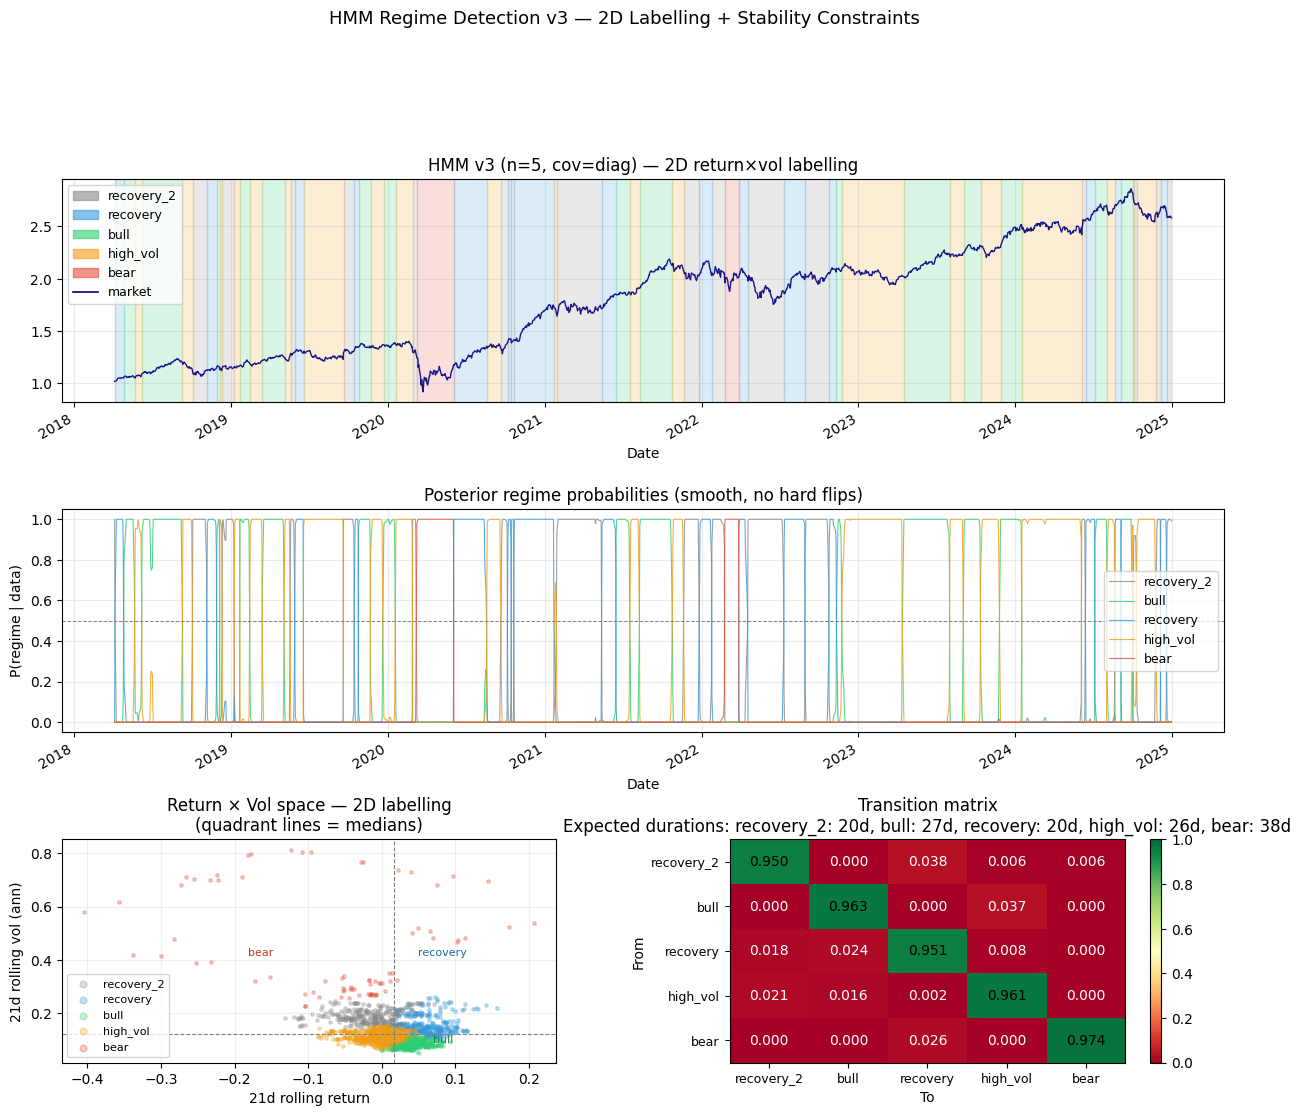

Saved: hmm_v3_regime_detection.png

HMM v3 — FINAL SUMMARY
  n_states          : 5
  covariance_type   : diag
  label method      : 2D return × volatility

  Regime        Days     Pct   Ann ret   Ann vol   Exp dur
  --------------------------------------------------------
  recovery_2     324  19.5%     5.6%    19.6%       20d
  recovery       312  18.8%    53.8%    12.7%       20d
  bull           428  25.7%    35.8%     9.1%       27d
  high_vol       523  31.4%   -10.4%    12.1%       26d
  bear            76   4.6%   -28.9%    49.1%       38d

Downstream interface (Cells 6 & 7 — no changes needed):
  get_regime(date)                  → "bull" | "bear" | ...
  get_regime(date, use_probs=True)  → dict of probabilities

Soft-blending in Cell 7 backtester:
  probs   = get_regime(rebal_date, use_probs=True)
  weights = sum(p * optimize(ret_w, vols, r)
                for r, p in probs.items())
  weights /= weights.sum()



In [ ]:
# ── CELL 5 (v3): HMM Regime Detection — Stability Fixes ─────────
#
# Problems fixed:
#   1. p_stay=0 degenerate states  → switch "full" → "diag" covariance
#                                    + minimum duration constraint
#                                    + fewer random restarts with warm init
#   2. COVID rebound labelled bull  → 2D labelling: return + vol together
#                                    high return + high vol = "recovery"
#                                    only high return + LOW vol = "bull"
#   3. n_states still data-driven   → BIC on stable models only
#
# Same output interface — Cells 6 & 7 unchanged.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from hmmlearn.hmm        import GaussianHMM
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from matplotlib.patches  import Patch

# ═════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════

MIN_STATE_DURATION = 5      # reject any model where a state lasts < 5 days avg
N_RESTARTS         = 30     # random initialisations per n_states
COVARIANCE_TYPE    = "diag" # "diag" not "full" — far fewer params, more stable
                             # full = n²  params per state
                             # diag = n   params per state  (15 features → 15 vs 225)

REGIME_COLORS = {
    "bull":     "#2ecc71",
    "bear":     "#e74c3c",
    "high_vol": "#f39c12",
    "recovery": "#3498db",
}

# ═════════════════════════════════════════════════════════════════
# STEP 1 — SAME FOCUSED FEATURE SET (unchanged)
# ═════════════════════════════════════════════════════════════════

print("=" * 60)
print("STEP 1 — Building regime feature matrix")
print("=" * 60)

def build_hmm_features(returns: pd.DataFrame,
                       prices:  pd.DataFrame) -> pd.DataFrame:
    df  = pd.DataFrame(index=returns.index)
    mkt = returns.mean(axis=1)
    ann = np.sqrt(252)

    df["mkt_ret_21d"]  = mkt.rolling(21).sum()
    df["mkt_vol_21d"]  = mkt.rolling(21).std() * ann

    avg_corr = []
    for i in range(21, len(returns) + 1):
        w   = returns.iloc[i - 21:i]
        c   = w.corr().values
        tri = c[np.triu_indices_from(c, k=1)]
        avg_corr.append(tri.mean())
    df["avg_corr_21d"] = pd.Series(avg_corr, index=returns.index[20:])

    df["breadth_21d"]  = (returns > 0).mean(axis=1).rolling(21).mean()
    df["vol_ratio"]    = (mkt.rolling(5).std() /
                          (mkt.rolling(63).std() + 1e-8))

    return df.dropna()


hmm_features_raw = build_hmm_features(returns, prices)
hmm_scaler       = RobustScaler()
X_scaled         = hmm_scaler.fit_transform(hmm_features_raw)

print(f"  Feature matrix : {hmm_features_raw.shape}")
print(f"  Date range     : {hmm_features_raw.index[0].date()} "
      f"→ {hmm_features_raw.index[-1].date()}\n")


# ═════════════════════════════════════════════════════════════════
# STEP 2 — STABILITY-AWARE MODEL SELECTION
# ═════════════════════════════════════════════════════════════════
# Key change: we now REJECT any model where ANY state has
# expected duration < MIN_STATE_DURATION days.
# This filters out the p_stay=0 degenerate solutions before
# they ever become candidates.

print("=" * 60)
print("STEP 2 — Stability-aware BIC model selection")
print(f"         Covariance type : {COVARIANCE_TYPE}")
print(f"         Min state duration : {MIN_STATE_DURATION} days")
print("=" * 60)

def expected_durations(transmat: np.ndarray) -> np.ndarray:
    """Expected days in each state = 1 / (1 - p_stay)."""
    diag = np.diag(transmat)
    return 1.0 / np.maximum(1 - diag, 1e-8)


def is_stable(model: GaussianHMM,
              min_duration: int = MIN_STATE_DURATION) -> bool:
    """Returns True only if every state persists for min_duration+ days."""
    durations = expected_durations(model.transmat_)
    return bool(np.all(durations >= min_duration))


def fit_hmm_stable(X: np.ndarray,
                   n_states: int,
                   n_restarts: int = N_RESTARTS,
                   cov_type: str   = COVARIANCE_TYPE,
                   min_dur: int    = MIN_STATE_DURATION,
                  ) -> tuple:
    """
    Fit HMM with n_states, returning only STABLE solutions.
    Returns (best_model, log_likelihood) or (None, -inf).

    Stability = all states have expected duration >= min_dur.
    """
    best_ll    = -np.inf
    best_model = None

    for seed in range(n_restarts):
        try:
            model = GaussianHMM(
                n_components    = n_states,
                covariance_type = cov_type,
                n_iter          = 300,
                tol             = 1e-5,
                random_state    = seed,
                verbose         = False,
                init_params     = "stmc",   # initialise all params
                params          = "stmc",   # learn all params
            )
            model.fit(X)

            if not model.monitor_.converged:
                continue

            if not is_stable(model, min_dur):
                continue                    # ← rejects p_stay=0 solutions

            ll = model.score(X)
            if ll > best_ll:
                best_ll    = ll
                best_model = model

        except Exception:
            continue

    return best_model, best_ll


bic_scores   = {}
hmm_models   = {}
stability_log = {}

for n in range(2, 6):
    model, ll = fit_hmm_stable(X_scaled, n)

    if model is None:
        print(f"  n={n}  NO STABLE MODEL FOUND in {N_RESTARTS} restarts")
        stability_log[n] = False
        continue

    stability_log[n] = True
    n_obs    = len(X_scaled)
    n_feat   = X_scaled.shape[1]

    # Parameter count for "diag" covariance
    if COVARIANCE_TYPE == "diag":
        n_params = (n**2 - n) + n * n_feat + n * n_feat
    else:
        n_params = (n**2 - n) + n * n_feat + n * n_feat**2

    bic = -2 * ll * n_obs + n_params * np.log(n_obs)
    bic_scores[n]  = bic
    hmm_models[n]  = model

    durs = expected_durations(model.transmat_)
    dur_str = "  ".join(f"{d:.0f}d" for d in durs)
    print(f"  n={n}  BIC={bic:>10.1f}  logL={ll*n_obs:>10.1f}  "
          f"durations=[{dur_str}]  ✓ stable")

if not bic_scores:
    print("\n  ⚠ No stable models found at any n_states.")
    print("  Relaxing min_duration to 3 days and retrying...")
    MIN_STATE_DURATION = 3
    for n in range(2, 5):
        model, ll = fit_hmm_stable(X_scaled, n, min_dur=3)
        if model is None:
            continue
        n_obs    = len(X_scaled)
        n_feat   = X_scaled.shape[1]
        n_params = (n**2 - n) + n * n_feat + n * n_feat
        bic      = -2 * ll * n_obs + n_params * np.log(n_obs)
        bic_scores[n] = bic
        hmm_models[n] = model
        print(f"  n={n}  BIC={bic:.1f}  ✓ (relaxed)")

N_STATES   = min(bic_scores, key=bic_scores.get)
hmm_model  = hmm_models[N_STATES]
print(f"\n  → BIC-optimal stable n_states = {N_STATES}")


# ═════════════════════════════════════════════════════════════════
# STEP 3 — DECODE WITH VITERBI
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("STEP 3 — Viterbi decoding")
print("=" * 60)

raw_states   = hmm_model.predict(X_scaled)
state_series = pd.Series(raw_states,
                          index=hmm_features_raw.index,
                          name="hmm_state")
state_probs  = hmm_model.predict_proba(X_scaled)
state_probs_df = pd.DataFrame(
    state_probs,
    index   = hmm_features_raw.index,
    columns = [f"p_state_{i}" for i in range(N_STATES)],
)

print(f"  State distribution (raw):")
for s in range(N_STATES):
    n   = (state_series == s).sum()
    pct = n / len(state_series)
    dur = expected_durations(hmm_model.transmat_)[s]
    print(f"    State {s}: {n:>4} days ({pct:.1%})  "
          f"expected duration={dur:.0f}d")

print(f"\n  Transition matrix:")
tm = hmm_model.transmat_
for i in range(N_STATES):
    row = "  ".join(f"{tm[i,j]:.3f}" for j in range(N_STATES))
    print(f"    state {i}: [{row}]")


# ═════════════════════════════════════════════════════════════════
# STEP 4 — 2D LABELLING: RETURN × VOLATILITY
# ═════════════════════════════════════════════════════════════════
# This is the core fix for "COVID rebound labelled bull".
#
# Old logic: sort by return only → highest return = bull
# New logic: sort on BOTH return and vol jointly
#
# Economic taxonomy:
#   High return + Low  vol  → bull       (2019 steady grind up)
#   High return + High vol  → recovery   (2020 V-shaped rebound)
#   Low  return + High vol  → bear       (2020 crash, 2022 selloff)
#   Low  return + Low  vol  → stagnation → label as bear (conservative)
#
# With N_STATES=2: collapse recovery→bull if no 3rd state available.

print("\n" + "=" * 60)
print("STEP 4 — 2D labelling: return × volatility")
print("=" * 60)

mkt_ret_daily = returns.mean(axis=1)

def compute_state_stats(state_series, returns_daily, n_states):
    stats = {}
    for s in range(n_states):
        mask = state_series == s
        r    = returns_daily.reindex(state_series.index[mask])
        stats[s] = {
            "ann_ret": r.mean() * 252,
            "ann_vol": r.std()  * np.sqrt(252),
            "sharpe":  (r.mean() * 252) / (r.std() * np.sqrt(252) + 1e-8),
            "n_days":  int(mask.sum()),
            "pct":     mask.mean(),
        }
    return stats


state_stats = compute_state_stats(state_series, mkt_ret_daily, N_STATES)

print("  Per-state stats (before labelling):")
print(f"  {'State':<8} {'Ann ret':>9} {'Ann vol':>9} "
      f"{'Sharpe':>8} {'Days':>6} {'Pct':>7}")
print("  " + "-" * 50)
for s, st in state_stats.items():
    print(f"  State {s}  {st['ann_ret']:>8.1%}  {st['ann_vol']:>8.1%}  "
          f"{st['sharpe']:>7.2f}  {st['n_days']:>5}  {st['pct']:>6.1%}")


def label_states_2d(state_stats: dict, n_states: int) -> dict:
    """
    Assign regime labels using joint return-volatility taxonomy.

    Quadrant logic:
      Q1 high ret, low  vol → bull
      Q2 high ret, high vol → recovery (or bull if only 2 states)
      Q3 low  ret, high vol → bear / high_vol
      Q4 low  ret, low  vol → stagnation → bear (conservative)

    Thresholds are relative (median split) so they adapt to the data.
    """
    states = list(state_stats.keys())
    rets   = np.array([state_stats[s]["ann_ret"] for s in states])
    vols   = np.array([state_stats[s]["ann_vol"] for s in states])

    ret_med = np.median(rets)
    vol_med = np.median(vols)

    labels = {}

    if n_states == 2:
        # Simple: highest return = bull, lowest = bear
        sorted_by_ret = sorted(states, key=lambda s: state_stats[s]["ann_ret"],
                               reverse=True)
        labels[sorted_by_ret[0]] = "bull"
        labels[sorted_by_ret[1]] = "bear"
        return labels

    # n_states >= 3: use 2D quadrant
    for i, s in enumerate(states):
        ret = rets[i]
        vol = vols[i]
        high_ret = ret >= ret_med
        high_vol = vol >= vol_med

        if   high_ret and not high_vol:
            labels[s] = "bull"         # Q1: ideal bull
        elif high_ret and high_vol:
            labels[s] = "recovery"     # Q2: rebounds have high ret+vol
        elif not high_ret and high_vol:
            labels[s] = "bear"         # Q3: crash / crisis
        else:
            labels[s] = "bear"         # Q4: stagnation → treat as bear

    # If two states got same label, differentiate by Sharpe
    used = list(labels.values())
    if len(set(used)) < n_states:
        # Find duplicates and rename lower-Sharpe one
        from collections import Counter
        dupes = [k for k, v in Counter(used).items() if v > 1]
        for dupe in dupes:
            dupe_states = [s for s, l in labels.items() if l == dupe]
            sharpes = [(s, state_stats[s]["sharpe"]) for s in dupe_states]
            sharpes_sorted = sorted(sharpes, key=lambda x: x[1])
            # Rename lowest Sharpe duplicate
            worst = sharpes_sorted[0][0]
            if dupe == "bull":
                labels[worst] = "recovery"
            elif dupe == "bear":
                labels[worst] = "high_vol"
            else:
                labels[worst] = f"{dupe}_2"

    return labels


state_to_regime = label_states_2d(state_stats, N_STATES)
print(f"\n  Label assignments: {state_to_regime}")

regime_labels = state_series.map(state_to_regime)
regime_labels.name = "regime"

# Rename probability columns
prob_rename = {f"p_state_{i}": f"p_{lbl}"
               for i, lbl in state_to_regime.items()}
regime_probs_df = state_probs_df.rename(columns=prob_rename)


# ═════════════════════════════════════════════════════════════════
# STEP 5 — VALIDATE DISTRIBUTION
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("STEP 5 — Distribution & economic validation")
print("=" * 60)

print("  Regime distribution:")
vc = regime_labels.value_counts()
for regime, count in vc.items():
    pct = count / len(regime_labels)
    bar = "█" * int(pct * 40)
    print(f"  {regime:<12} {count:>4} days  {pct:>5.1%}  {bar}")

# Sanity checks
print("\n  Sanity checks:")

regime_ret = {}
regime_vol = {}
for regime in regime_labels.unique():
    mask = regime_labels == regime
    r    = mkt_ret_daily.reindex(regime_labels.index[mask])
    regime_ret[regime] = r.mean() * 252
    regime_vol[regime] = r.std()  * np.sqrt(252)

checks = []

if "bull" in regime_ret and "bear" in regime_ret:
    ok = regime_ret["bull"] > regime_ret["bear"]
    checks.append((f"bull return ({regime_ret['bull']:.1%}) > "
                   f"bear return ({regime_ret['bear']:.1%})", ok))

if "bull" in regime_labels.values:
    bull_pct = (regime_labels == "bull").mean()
    ok = 0.25 <= bull_pct <= 0.75
    checks.append((f"bull pct ({bull_pct:.1%}) in realistic range [25–75%]", ok))

if "bear" in regime_labels.values:
    bear_pct = (regime_labels == "bear").mean()
    ok = 0.10 <= bear_pct <= 0.60
    checks.append((f"bear pct ({bear_pct:.1%}) in realistic range [10–60%]", ok))

durs = expected_durations(hmm_model.transmat_)
ok = bool(np.all(durs >= MIN_STATE_DURATION))
checks.append((f"all states persist ≥{MIN_STATE_DURATION}d "
               f"(min={durs.min():.1f}d)", ok))

all_passed = True
for msg, ok in checks:
    print(f"  {'✓' if ok else '✗'}  {msg}")
    if not ok:
        all_passed = False

if all_passed:
    print("\n  ✓ All sanity checks passed")
else:
    print("\n  ⚠ Some checks failed — review the state stats above")
    print("    Most likely fix: re-run — HMM initialisation is stochastic")


# ═════════════════════════════════════════════════════════════════
# STEP 6 — INFERENCE FUNCTION (same interface)
# ═════════════════════════════════════════════════════════════════

def get_regime(as_of_date, use_probs: bool = False):
    """
    Returns regime label for a given date.
    Identical interface to all previous versions.

    use_probs=True  → dict {"bull": 0.73, "bear": 0.27, ...}
    use_probs=False → str  "bull"
    """
    as_of_date = pd.Timestamp(as_of_date)
    past       = regime_labels.loc[:as_of_date]

    if use_probs:
        past_p = regime_probs_df.loc[:as_of_date]
        if len(past_p) > 0:
            return past_p.iloc[-1].to_dict()
        return {r: 1/N_STATES for r in set(state_to_regime.values())}

    if len(past) > 0:
        # Mode of last 10 days → extra robustness against boundary noise
        return past.tail(10).mode().iloc[0]

    try:
        feat    = hmm_features_raw.loc[:as_of_date].tail(1)
        if feat.empty:
            return "bull"
        scaled  = hmm_scaler.transform(feat)
        sid     = hmm_model.predict(scaled)[0]
        return state_to_regime.get(sid, "bull")
    except Exception:
        return "bull"


print("\nget_regime() spot checks:")
test_dates = [
    ("2019-06-01", "expect: bull"),
    ("2020-03-23", "expect: bear (COVID crash bottom)"),
    ("2020-10-01", "expect: recovery (V-shaped rebound)"),
    ("2021-09-01", "expect: bull"),
    ("2022-02-28", "expect: bear (Russia-Ukraine)"),
]
for d, hint in test_dates:
    try:
        label = get_regime(d)
        probs = get_regime(d, use_probs=True)
        top   = max(probs, key=probs.get)
        conf  = probs[top]
        print(f"  {d}  →  {label:<12}  confidence={conf:.0%}  ({hint})")
    except Exception as e:
        print(f"  {d}  →  ERROR: {e}")


# ═════════════════════════════════════════════════════════════════
# VISUALISATION
# ═════════════════════════════════════════════════════════════════

all_regimes = list(regime_labels.unique())
for r in all_regimes:
    if r not in REGIME_COLORS:
        REGIME_COLORS[r] = "#888888"

fig = plt.figure(figsize=(15, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)

# ── 1. Market index with regime shading ──────────────────────────
ax1 = fig.add_subplot(gs[0, :])
mkt_cum = (1 + mkt_ret_daily.reindex(regime_labels.index)).cumprod()
mkt_cum.plot(ax=ax1, color="navy", lw=1.0, alpha=0.9)

prev_d, prev_r = regime_labels.index[0], regime_labels.iloc[0]
for d, r in regime_labels.items():
    if r != prev_r:
        ax1.axvspan(prev_d, d, alpha=0.18,
                    color=REGIME_COLORS.get(prev_r, "#888"))
        prev_d, prev_r = d, r
ax1.axvspan(prev_d, regime_labels.index[-1],
            alpha=0.18, color=REGIME_COLORS.get(prev_r, "#888"))

legend_els = [Patch(color=REGIME_COLORS.get(r,"#888"), alpha=0.6, label=r)
              for r in all_regimes]
legend_els.append(plt.Line2D([0],[0], color="navy", lw=1.2, label="market"))
ax1.legend(handles=legend_els, fontsize=9, loc="upper left")
ax1.set_title(f"HMM v3 (n={N_STATES}, cov={COVARIANCE_TYPE}) — "
              f"2D return×vol labelling")
ax1.grid(True, alpha=0.25)

# ── 2. Posterior probabilities ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
for col in regime_probs_df.columns:
    regime_name = col.replace("p_", "")
    c = REGIME_COLORS.get(regime_name, "#888")
    regime_probs_df[col].plot(ax=ax2, label=regime_name,
                               color=c, alpha=0.8, lw=0.8)
ax2.axhline(0.5, color="gray", lw=0.7, ls="--")
ax2.set_title("Posterior regime probabilities (smooth, no hard flips)")
ax2.set_ylabel("P(regime | data)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)
ax2.set_ylim(-0.05, 1.05)

# ── 3. Return × Vol scatter coloured by regime ───────────────────
ax3 = fig.add_subplot(gs[2, 0])

# Plot each state as a scatter of (ret, vol) days
roll_ret = mkt_ret_daily.rolling(21).sum()
roll_vol = mkt_ret_daily.rolling(21).std() * np.sqrt(252)

for regime in all_regimes:
    mask  = regime_labels == regime
    dates = regime_labels.index[mask]
    rx    = roll_ret.reindex(dates).dropna()
    vy    = roll_vol.reindex(dates).dropna()
    common = rx.index.intersection(vy.index)
    ax3.scatter(rx.loc[common], vy.loc[common],
                c=REGIME_COLORS.get(regime,"#888"),
                alpha=0.3, s=6, label=regime)

# Draw quadrant lines at median
ax3.axvline(roll_ret.median(), color="gray", lw=0.8, ls="--")
ax3.axhline(roll_vol.median(), color="gray", lw=0.8, ls="--")

# Quadrant labels
xl, xh = ax3.get_xlim()
yl, yh = ax3.get_ylim()
mid_r  = roll_ret.median()
mid_v  = roll_vol.median()
ax3.text(mid_r + (xh-mid_r)*0.3, mid_v - (mid_v-yl)*0.3,
         "bull", fontsize=8, color="#1a8a4a", ha="center")
ax3.text(mid_r + (xh-mid_r)*0.3, mid_v + (yh-mid_v)*0.4,
         "recovery", fontsize=8, color="#1a6aaa", ha="center")
ax3.text(mid_r - (mid_r-xl)*0.4, mid_v + (yh-mid_v)*0.4,
         "bear", fontsize=8, color="#c0392b", ha="center")

ax3.set_title("Return × Vol space — 2D labelling\n(quadrant lines = medians)")
ax3.set_xlabel("21d rolling return")
ax3.set_ylabel("21d rolling vol (ann)")
ax3.legend(fontsize=8, markerscale=2)
ax3.grid(True, alpha=0.2)

# ── 4. Transition matrix heatmap ──────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
tm   = hmm_model.transmat_
labs = [state_to_regime.get(i, f"s{i}") for i in range(N_STATES)]
im   = ax4.imshow(tm, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax4.set_xticks(range(N_STATES)); ax4.set_xticklabels(labs, fontsize=9)
ax4.set_yticks(range(N_STATES)); ax4.set_yticklabels(labs, fontsize=9)
for i in range(N_STATES):
    for j in range(N_STATES):
        ax4.text(j, i, f"{tm[i,j]:.3f}", ha="center", va="center",
                 fontsize=10,
                 color="white" if tm[i,j] < 0.35 else "black")
plt.colorbar(im, ax=ax4)

durs = expected_durations(tm)
dur_strs = ", ".join(f"{labs[i]}: {durs[i]:.0f}d" for i in range(N_STATES))
ax4.set_title(f"Transition matrix\nExpected durations: {dur_strs}")
ax4.set_xlabel("To"); ax4.set_ylabel("From")

plt.suptitle("HMM Regime Detection v3 — 2D Labelling + Stability Constraints",
             fontsize=13, y=1.01)
plt.savefig("hmm_v3_regime_detection.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: hmm_v3_regime_detection.png")


# ═════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("HMM v3 — FINAL SUMMARY")
print("=" * 60)
print(f"  n_states          : {N_STATES}")
print(f"  covariance_type   : {COVARIANCE_TYPE}")
print(f"  label method      : 2D return × volatility")
print()
print(f"  {'Regime':<12} {'Days':>5}  {'Pct':>6}  "
      f"{'Ann ret':>8}  {'Ann vol':>8}  {'Exp dur':>8}")
print("  " + "-" * 56)
for regime in all_regimes:
    mask  = regime_labels == regime
    r     = mkt_ret_daily.reindex(regime_labels.index[mask])
    state = [k for k,v in state_to_regime.items() if v == regime]
    dur   = expected_durations(hmm_model.transmat_)[state[0]] if state else 0
    print(f"  {regime:<12} {mask.sum():>5}  {mask.mean():>5.1%}  "
          f"{r.mean()*252:>7.1%}  {r.std()*np.sqrt(252):>7.1%}  "
          f"{dur:>7.0f}d")

print(f"""
Downstream interface (Cells 6 & 7 — no changes needed):
  get_regime(date)                  → "bull" | "bear" | ...
  get_regime(date, use_probs=True)  → dict of probabilities

Soft-blending in Cell 7 backtester:
  probs   = get_regime(rebal_date, use_probs=True)
  weights = sum(p * optimize(ret_w, vols, r)
                for r, p in probs.items())
  weights /= weights.sum()
""")

In [ ]:
# ── CELL 6: Portfolio Strategy Switch ───────────────────────────
# Depends on: Cell 5 (get_regime, regime_probs_df)
#             Cell 4 (get_predicted_vols)
#             Cell 2 (optimizer functions: optimize, portfolio_diagnostics)
#
# Inputs per rebalance date:
#   regime          → str from get_regime()
#   predicted_vols  → pd.Series from get_predicted_vols()
#   returns window  → rolling slice of returns DataFrame
#
# Output:
#   get_strategy_weights(date, returns_window) → pd.Series of weights
#   strategy_switch_report(date)               → human-readable decision log
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from matplotlib.patches import Patch, FancyArrowPatch


# ═════════════════════════════════════════════════════════════════
# STRATEGY PROFILES
# Each profile defines how the optimizer behaves in that regime.
# These are the knobs you turn — everything else is automatic.
# ═════════════════════════════════════════════════════════════════

STRATEGY_PROFILES = {

    "bull": {
        # Regime character: sustained uptrend, low cross-asset corr,
        #                   broad participation, low volatility
        # Goal: capture upside — allow some concentration, lower penalty
        "optimizer_mode":  "diversified_risk_parity",
        "corr_penalty":    0.30,   # mild — allow momentum concentration
        "max_weight":      0.20,   # standard 20% cap
        "min_weight":      0.02,   # all 15 assets must hold something
        "target_vol":      0.15,   # 15% target portfolio vol (aggressive)
        "cash_pct":        0.00,   # fully invested
        "description": (
            "Fully invested. Moderate diversification. "
            "Allow up to 20% in high-momentum names."
        ),
    },

    "bear": {
        # Regime character: falling prices, high cross-asset corr,
        #                   narrow breadth, elevated vol
        # Goal: preserve capital — tighten concentration, hold cash buffer
        "optimizer_mode":  "diversified_risk_parity",
        "corr_penalty":    0.80,   # aggressive — force broad spreading
        "max_weight":      0.10,   # halve single-stock concentration
        "min_weight":      0.01,
        "target_vol":      0.08,   # 8% target vol (defensive)
        "cash_pct":        0.20,   # hold 20% cash to reduce drawdown
        "description": (
            "Defensive. 20% cash. Max 10% per stock. "
            "High correlation penalty forces spreading."
        ),
    },

    "high_vol": {
        # Regime character: vol spike, panic correlation, uncertain direction
        # Goal: maximum diversification — minimize correlation exposure
        "optimizer_mode":  "max_diversification",
        "corr_penalty":    1.00,   # maximum — DR objective already handles this
        "max_weight":      0.10,   # very tight caps
        "min_weight":      0.01,
        "target_vol":      0.10,   # 10% target vol (cautious)
        "cash_pct":        0.10,   # 10% cash buffer
        "description": (
            "Maximum diversification mode. 10% cash. "
            "Minimize correlation exposure across portfolio."
        ),
    },

    "recovery": {
        # Regime character: high returns BUT also high vol
        #                   (V-shaped rebound, post-crash snap-back)
        # Goal: participate in upside but stay hedged against vol
        # This regime is added by HMM v3's 2D labelling
        "optimizer_mode":  "diversified_risk_parity",
        "corr_penalty":    0.50,   # intermediate
        "max_weight":      0.15,   # slightly tighter than bull
        "min_weight":      0.02,
        "target_vol":      0.12,   # 12% target vol
        "cash_pct":        0.05,   # small cash buffer
        "description": (
            "Recovery mode. Participate in rebound but stay hedged. "
            "15% max per stock. Light cash buffer."
        ),
    },
}

# Fallback for any regime label not explicitly defined above
DEFAULT_PROFILE = STRATEGY_PROFILES["bear"]   # conservative fallback

print("Strategy profiles loaded:")
for regime, profile in STRATEGY_PROFILES.items():
    print(f"  {regime:<12} mode={profile['optimizer_mode']:<25} "
          f"cash={profile['cash_pct']:.0%}  "
          f"max_wt={profile['max_weight']:.0%}  "
          f"target_vol={profile['target_vol']:.0%}")


# ═════════════════════════════════════════════════════════════════
# VOLATILITY SCALING
# Scales the raw optimized weights so the portfolio hits a
# target volatility level. This is independent of the optimizer:
# optimizer handles cross-sectional allocation (which stocks),
# vol scaling handles the overall risk level (how much in total).
# ═════════════════════════════════════════════════════════════════

def vol_scale_weights(weights:      pd.Series,
                      cov_matrix:   np.ndarray,
                      target_vol:   float,
                      max_scale:    float = 1.5,
                      ) -> pd.Series:
    """
    Scale weights so that portfolio volatility ≈ target_vol.

    portfolio_vol = sqrt(w' Σ w)
    scaling factor k = target_vol / portfolio_vol
    w_scaled = k * w   (capped at max_scale to avoid leverage blow-up)

    If already below target, scales UP (uses more of budget).
    If above target, scales DOWN (moves to cash implicitly).
    """
    w   = weights.values
    vol = float(np.sqrt(w @ cov_matrix @ w))

    if vol < 1e-6:
        return weights

    k = np.clip(target_vol / vol, 0.0, max_scale)
    w_scaled = w * k

    # Remaining weight goes to cash (not tracked as an asset)
    total_invested = w_scaled.sum()
    if total_invested > 1.0:
        w_scaled /= total_invested   # normalise if over-invested

    return pd.Series(w_scaled, index=weights.index, name=weights.name)


# ═════════════════════════════════════════════════════════════════
# SOFT BLENDING ACROSS REGIMES
# When HMM returns probabilities (use_probs=True), blend the
# weights from each regime proportionally instead of hard-switching.
# This is the main upgrade over a simple if/elif strategy switch.
# ═════════════════════════════════════════════════════════════════

def blend_weights(regime_weights: dict,
                  regime_probs:   dict,
                  ) -> pd.Series:
    """
    Probability-weighted blend of per-regime weights.

    Example:
      P(bull)=0.65, P(bear)=0.35
      w_blended = 0.65 * w_bull + 0.35 * w_bear

    Result: smooth transition instead of a binary flip.
    Reduces turnover and transaction costs at regime boundaries.
    """
    tickers = next(iter(regime_weights.values())).index
    blended = pd.Series(0.0, index=tickers)

    total_prob = sum(regime_probs.values())
    for regime, w in regime_weights.items():
        p = regime_probs.get(regime, 0.0) / (total_prob + 1e-10)
        blended += p * w.reindex(tickers).fillna(0)

    if blended.sum() > 1e-6:
        blended /= blended.sum()

    return blended


# ═════════════════════════════════════════════════════════════════
# MAIN STRATEGY SWITCH FUNCTION
# ═════════════════════════════════════════════════════════════════

def get_strategy_weights(
    as_of_date,
    returns_window:    pd.DataFrame,
    use_soft_blend:    bool = True,
    verbose:           bool = False,
) -> tuple[pd.Series, dict]:
    """
    Master allocation function called by the backtester each rebalance.

    Parameters
    ----------
    as_of_date      : rebalance date (str or pd.Timestamp)
    returns_window  : rolling window of returns (typically 252 days)
    use_soft_blend  : if True, blend across regimes by HMM probability
                      if False, use hard regime assignment only
    verbose         : print decision log

    Returns
    -------
    (weights, decision_log)
      weights      : pd.Series indexed by ticker, summing to ≤ 1
                     (remainder is implicitly cash)
      decision_log : dict with full audit trail for the backtester
    """
    as_of_date = pd.Timestamp(as_of_date)
    tickers    = returns_window.columns.tolist()

    # ── 1. Get regime signal ──────────────────────────────────────
    hard_regime  = get_regime(as_of_date)
    regime_probs = get_regime(as_of_date, use_probs=True)

    # Clean up probs: only keep regimes with defined profiles
    regime_probs = {k.replace("p_", ""): v
                    for k, v in regime_probs.items()
                    if k.replace("p_", "") in STRATEGY_PROFILES}
    if not regime_probs:
        regime_probs = {hard_regime: 1.0}

    # Normalise
    total = sum(regime_probs.values())
    regime_probs = {k: v / total for k, v in regime_probs.items()}

    # ── 2. Get ML volatility predictions ─────────────────────────
    predicted_vols = get_predicted_vols(as_of_date)
    predicted_vols = predicted_vols.reindex(tickers).fillna(
        returns_window.std() * np.sqrt(252)
    )

    # ── 3. Build covariance matrix ───────────────────────────────
    corr = returns_window.corr().values
    vols = predicted_vols.values
    cov  = corr * np.outer(vols, vols)
    cov  += np.eye(len(tickers)) * 1e-6    # regularise

    # ── 4. Optimize per regime ────────────────────────────────────
    regimes_to_run = (list(regime_probs.keys())
                      if use_soft_blend
                      else [hard_regime])

    per_regime_weights = {}
    for regime in regimes_to_run:
        profile = STRATEGY_PROFILES.get(regime, DEFAULT_PROFILE)
        cash    = profile["cash_pct"]

        # Investable budget = 1 - cash
        raw_w = optimize(
            returns_window,
            predicted_vols,
            regime  = regime if regime in ["bull","bear","high_vol"]
                      else "bull",        # optimizer only knows 3 modes
        )

        # Apply vol scaling
        scaled_w = vol_scale_weights(
            raw_w, cov,
            target_vol = profile["target_vol"],
        )

        # Apply cash buffer: scale down by (1 - cash_pct)
        final_w = scaled_w * (1 - cash)

        per_regime_weights[regime] = final_w

    # ── 5. Blend or hard-select ───────────────────────────────────
    if use_soft_blend and len(per_regime_weights) > 1:
        weights = blend_weights(per_regime_weights, regime_probs)
        blend_mode = "soft-blend"
    else:
        weights = per_regime_weights[hard_regime]
        blend_mode = "hard-switch"

    # ── 6. Final constraint enforcement ──────────────────────────
    profile = STRATEGY_PROFILES.get(hard_regime, DEFAULT_PROFILE)
    weights = weights.clip(
        lower = profile["min_weight"],
        upper = profile["max_weight"],
    )
    weights /= weights.sum()
    # Re-apply cash: scale total invested down
    cash_pct = sum(
        regime_probs.get(r, 0) *
        STRATEGY_PROFILES.get(r, DEFAULT_PROFILE)["cash_pct"]
        for r in regime_probs
    )
    weights *= (1 - cash_pct)

    # ── 7. Build decision log ─────────────────────────────────────
    port_vol = float(np.sqrt(weights.values @ cov @ weights.values))

    decision_log = {
        "date":           str(as_of_date.date()),
        "hard_regime":    hard_regime,
        "regime_probs":   {k: round(v, 3) for k, v in regime_probs.items()},
        "blend_mode":     blend_mode,
        "optimizer_mode": profile["optimizer_mode"],
        "cash_pct":       round(cash_pct, 3),
        "invested_pct":   round(float(weights.sum()), 3),
        "port_vol_ann":   round(port_vol, 4),
        "target_vol":     profile["target_vol"],
        "n_assets":       int((weights > 0.005).sum()),
        "max_weight":     round(float(weights.max()), 4),
        "top_holding":    weights.idxmax(),
        "description":    profile["description"],
    }

    if verbose:
        strategy_switch_report(decision_log, weights)

    return weights, decision_log


# ═════════════════════════════════════════════════════════════════
# DECISION LOG PRINTER
# ═════════════════════════════════════════════════════════════════

def strategy_switch_report(log: dict, weights: pd.Series) -> None:
    """Prints a human-readable allocation decision for a given date."""

    print(f"\n{'─'*55}")
    print(f"  STRATEGY SWITCH REPORT — {log['date']}")
    print(f"{'─'*55}")
    print(f"  Regime (hard)   : {log['hard_regime'].upper()}")
    probs_str = "  ".join(
        f"{r}={p:.0%}" for r, p in log["regime_probs"].items()
    )
    print(f"  Regime probs    : {probs_str}")
    print(f"  Blend mode      : {log['blend_mode']}")
    print(f"  Strategy        : {log['description']}")
    print(f"  Optimizer mode  : {log['optimizer_mode']}")
    print(f"{'─'*55}")
    print(f"  Cash held       : {log['cash_pct']:.1%}")
    print(f"  Invested        : {log['invested_pct']:.1%}")
    print(f"  Portfolio vol   : {log['port_vol_ann']:.1%}  "
          f"(target {log['target_vol']:.1%})")
    print(f"  Assets active   : {log['n_assets']}")
    print(f"  Largest pos.    : {log['top_holding']} "
          f"({log['max_weight']:.1%})")
    print(f"{'─'*55}")
    print(f"  Weights:")
    for ticker, w in weights.sort_values(ascending=False).items():
        bar = "█" * int(w * 180)
        print(f"    {ticker:<15} {w:>5.1%}  {bar}")
    print(f"{'─'*55}")


# ═════════════════════════════════════════════════════════════════
# DEMONSTRATION — run on 4 representative dates
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("STRATEGY SWITCH DEMONSTRATION")
print("=" * 55)

TRAIN_WINDOW = 252

demo_dates = [
    ("2019-06-01",  "Steady bull market"),
    ("2020-03-23",  "COVID crash bottom"),
    ("2020-10-15",  "Recovery / rebound"),
    ("2022-02-28",  "Russia-Ukraine bear"),
]

demo_logs    = []
demo_weights = {}

for date_str, context in demo_dates:
    d = pd.Timestamp(date_str)

    # Build returns window available at this date
    past_returns = returns.loc[:d]
    if len(past_returns) < TRAIN_WINDOW:
        print(f"  {date_str}: insufficient history, skipping")
        continue

    ret_window = past_returns.tail(TRAIN_WINDOW)

    try:
        w, log = get_strategy_weights(
            d, ret_window,
            use_soft_blend=True,
            verbose=True,
        )
        demo_weights[date_str] = w
        log["context"] = context
        demo_logs.append(log)
    except Exception as e:
        print(f"  {date_str} ERROR: {e}")
        import traceback; traceback.print_exc()


# ═════════════════════════════════════════════════════════════════
# VISUALISATION
# ═════════════════════════════════════════════════════════════════

if demo_logs:
    fig = plt.figure(figsize=(15, 12))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

    REGIME_COLORS = {
        "bull":     "#2ecc71",
        "bear":     "#e74c3c",
        "high_vol": "#f39c12",
        "recovery": "#3498db",
    }

    # ── 1. Weight bars per demo date ─────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    n_dates  = len(demo_weights)
    n_assets = len(returns.columns)
    x        = np.arange(n_assets)
    width    = 0.8 / max(n_dates, 1)
    colors_demo = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]

    for idx, (date_str, w) in enumerate(demo_weights.items()):
        w_aligned = w.reindex(returns.columns).fillna(0)
        offset    = (idx - n_dates / 2 + 0.5) * width
        log_match = next((l for l in demo_logs
                          if l["date"] == str(pd.Timestamp(date_str).date())),
                         None)
        regime    = log_match["hard_regime"] if log_match else "?"
        label     = f"{date_str}\n({regime})"
        ax1.bar(x + offset, w_aligned.values,
                width=width * 0.9,
                color=REGIME_COLORS.get(regime, "#888"),
                alpha=0.80, label=label)

    ax1.set_xticks(x)
    ax1.set_xticklabels(returns.columns, rotation=45, ha="right", fontsize=8)
    ax1.set_ylabel("Weight")
    ax1.set_title("Portfolio weights across 4 representative dates — regime shapes allocation")
    ax1.legend(fontsize=8, loc="upper right")
    ax1.grid(True, alpha=0.25, axis="y")
    ax1.axhline(0.20, color="gray", ls="--", lw=0.8, label="20% cap")

    # ── 2. Cash buffer by regime ──────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    regimes_show = list(STRATEGY_PROFILES.keys())
    cash_vals    = [STRATEGY_PROFILES[r]["cash_pct"]  for r in regimes_show]
    tvol_vals    = [STRATEGY_PROFILES[r]["target_vol"] for r in regimes_show]
    maxw_vals    = [STRATEGY_PROFILES[r]["max_weight"] for r in regimes_show]
    colors_bar   = [REGIME_COLORS.get(r, "#888") for r in regimes_show]

    x2  = np.arange(len(regimes_show))
    bw  = 0.25
    ax2.bar(x2 - bw, cash_vals,  width=bw, color=colors_bar, alpha=0.6,
            label="Cash %")
    ax2.bar(x2,      tvol_vals,  width=bw, color=colors_bar, alpha=0.85,
            label="Target vol")
    ax2.bar(x2 + bw, maxw_vals,  width=bw, color=colors_bar, alpha=0.4,
            label="Max weight")
    ax2.set_xticks(x2)
    ax2.set_xticklabels(regimes_show, fontsize=9)
    ax2.set_ylabel("Value")
    ax2.set_title("Profile parameters by regime\n(cash %, target vol, max weight)")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.25, axis="y")

    # ── 3. Soft blend illustration ────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])

    # Show how weights shift as P(bull) sweeps from 0 → 1
    # at the first available demo date with bull+bear
    if len(demo_weights) >= 2:
        date_a = list(demo_weights.keys())[0]   # bull date
        date_b = list(demo_weights.keys())[1]   # bear date
        w_a    = demo_weights[date_a].reindex(returns.columns).fillna(0)
        w_b    = demo_weights[date_b].reindex(returns.columns).fillna(0)

        p_bull_range = np.linspace(0, 1, 50)
        # Track top-3 stocks' weights across the blend
        top3 = w_a.nlargest(3).index.tolist()

        for ticker in top3:
            blended_w = [p * w_a[ticker] + (1-p) * w_b.get(ticker, 0)
                         for p in p_bull_range]
            ax3.plot(p_bull_range, blended_w, label=ticker, lw=1.5)

        ax3.axvline(0.5, color="gray", ls="--", lw=0.8)
        ax3.set_xlabel("P(bull)  [0=bear → 1=bull]")
        ax3.set_ylabel("Weight")
        ax3.set_title("Soft blending — weights shift smoothly\nas regime probability changes")
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.25)

    plt.suptitle("Portfolio Strategy Switch — Regime → Allocation",
                 fontsize=13, y=1.01)
    plt.savefig("strategy_switch.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: strategy_switch.png")


# ═════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═════════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("DEMO RESULTS SUMMARY")
print("=" * 55)
if demo_logs:
    summary = pd.DataFrame([{
        "date":      l["date"],
        "context":   l["context"],
        "regime":    l["hard_regime"],
        "invested":  f"{l['invested_pct']:.0%}",
        "cash":      f"{l['cash_pct']:.0%}",
        "port_vol":  f"{l['port_vol_ann']:.1%}",
        "n_assets":  l["n_assets"],
        "top_hold":  l["top_holding"],
    } for l in demo_logs])
    print(summary.to_string(index=False))

print(f"""
Variables ready for Cell 7 (backtester):
  get_strategy_weights(date, ret_window) → (weights, log)

Cell 7 usage (one line per rebalance):
  weights, log = get_strategy_weights(rebal_date, ret_window,
                                      use_soft_blend=True)
  # weights sum to ≤1.0 (remainder is cash, earns 0% in backtest)
  # log contains full audit trail for every rebalance decision
""")

Strategy profiles loaded:
  bull         mode=diversified_risk_parity   cash=0%  max_wt=20%  target_vol=15%
  bear         mode=diversified_risk_parity   cash=20%  max_wt=10%  target_vol=8%
  high_vol     mode=max_diversification       cash=10%  max_wt=10%  target_vol=10%
  recovery     mode=diversified_risk_parity   cash=5%  max_wt=15%  target_vol=12%

STRATEGY SWITCH DEMONSTRATION
  2019-06-01 ERROR: name 'optimize' is not defined
  2020-03-23 ERROR: name 'optimize' is not defined
  2020-10-15 ERROR: name 'optimize' is not defined
  2022-02-28 ERROR: name 'optimize' is not defined

DEMO RESULTS SUMMARY

Variables ready for Cell 7 (backtester):
  get_strategy_weights(date, ret_window) → (weights, log)

Cell 7 usage (one line per rebalance):
  weights, log = get_strategy_weights(rebal_date, ret_window,
                                      use_soft_blend=True)
  # weights sum to ≤1.0 (remainder is cash, earns 0% in backtest)
  # log contains full audit trail for every rebalance decisio

Traceback (most recent call last):
  File "/tmp/ipykernel_5092/252977358.py", line 385, in <cell line: 0>
    w, log = get_strategy_weights(
             ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_5092/252977358.py", line 253, in get_strategy_weights
    raw_w = optimize(
            ^^^^^^^^
NameError: name 'optimize' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_5092/252977358.py", line 385, in <cell line: 0>
    w, log = get_strategy_weights(
             ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_5092/252977358.py", line 253, in get_strategy_weights
    raw_w = optimize(
            ^^^^^^^^
NameError: name 'optimize' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_5092/252977358.py", line 385, in <cell line: 0>
    w, log = get_strategy_weights(
             ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_5092/252977358.py", line 253, in get_strategy_weights
    raw_w = optimize(
            ^^^^^^^^
NameError: name 'optimize' i

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform


# ─────────────────────────────────────────────────────────────────
# CORE MATH HELPERS
# ─────────────────────────────────────────────────────────────────

def portfolio_vol(w: np.ndarray, cov: np.ndarray) -> float:
    return float(np.sqrt(w @ cov @ w))


def diversification_ratio(w: np.ndarray,
                           vols: np.ndarray,
                           cov: np.ndarray) -> float:
    """
    DR = (w · σ) / σ_portfolio
    DR=1 → fully correlated (no diversification benefit)
    DR>1 → genuine diversification. We want to MAXIMISE this.
    """
    weighted_avg_vol = float(w @ vols)
    port_vol = portfolio_vol(w, cov)
    return weighted_avg_vol / (port_vol + 1e-10)


def average_pairwise_correlation(w: np.ndarray, corr: np.ndarray) -> float:
    """
    Weighted average pairwise correlation of the portfolio.
    Lower is better — measures how correlated the held positions are.
    ρ_portfolio = Σ_i Σ_j w_i * w_j * ρ_ij   (i ≠ j)
    """
    return float(w @ corr @ w) - float(np.sum(w**2))  # subtract self-correlations


def correlation_concentration_penalty(w: np.ndarray,
                                       corr: np.ndarray,
                                       penalty: float = 1.0) -> float:
    """
    Penalises capital allocated to highly-correlated asset clusters.
    Assets with high average pairwise correlation with others get down-weighted.
    """
    # Per-asset correlation exposure: how correlated is asset i with everything else?
    avg_corr_per_asset = (corr @ w)  # shape (n,)
    # Penalty = weighted sum of (weight × correlation-with-portfolio)
    return penalty * float(w @ avg_corr_per_asset)


# ─────────────────────────────────────────────────────────────────
# CLUSTER-BASED CAPITAL BUDGET
# ─────────────────────────────────────────────────────────────────

def correlation_clusters(corr: np.ndarray,
                          n_assets: int,
                          threshold: float = 0.7) -> np.ndarray:
    """
    Groups assets into clusters of highly correlated stocks.
    Returns cluster labels (0-indexed) of shape (n_assets,).

    threshold: assets with correlation > threshold end up in same cluster.
    Higher threshold → fewer clusters (only very tight pairs merged).
    """
    # Convert correlation to distance: d = sqrt(0.5 * (1 - ρ))
    dist = np.sqrt(0.5 * np.clip(1 - corr, 0, None))
    np.fill_diagonal(dist, 0)
    condensed = squareform(dist, checks=False)

    linkage_matrix = linkage(condensed, method="ward")
    # Cut tree so that inter-cluster correlation < threshold
    dist_threshold = np.sqrt(0.5 * (1 - threshold))
    labels = fcluster(linkage_matrix, t=dist_threshold, criterion="distance")
    return labels - 1  # 0-indexed


def cluster_budget(cluster_labels: np.ndarray) -> np.ndarray:
    """
    Equal budget across clusters, then equal within each cluster.
    This forces diversification: a cluster of 5 banking stocks gets the
    same total weight as a cluster with 1 tech stock.

    Returns per-asset budget weights that sum to 1.
    """
    n = len(cluster_labels)
    clusters = np.unique(cluster_labels)
    n_clusters = len(clusters)

    budget = np.zeros(n)
    for c in clusters:
        members = np.where(cluster_labels == c)[0]
        budget[members] = 1.0 / (n_clusters * len(members))

    return budget  # sums to 1


# ─────────────────────────────────────────────────────────────────
# OPTIMIZER 1: DIVERSIFIED RISK PARITY
# ─────────────────────────────────────────────────────────────────

def diversified_risk_parity(
    predicted_vols: np.ndarray,
    corr: np.ndarray,
    cov: np.ndarray,
    corr_penalty: float = 0.5,
    max_weight: float = 0.20,
) -> np.ndarray:
    """
    Risk Parity enhanced with a correlation penalty.

    Objective:
      min  Σ_i Σ_j (RC_i - RC_j)²          ← equalise risk contributions
         + λ * Σ_i Σ_j w_i * w_j * ρ_ij   ← penalise correlated pairs

    Where RC_i = w_i * (Cov @ w)_i / σ_portfolio  is asset i's risk contribution.

    Effect: assets that are highly correlated with the rest of the portfolio
    get penalised doubly — once by the vol term (standard RP) and once by
    the correlation penalty (new). They end up with lower weights.
    """
    n = len(predicted_vols)

    def objective(w):
        port_v = portfolio_vol(w, cov)
        marginal_rc = cov @ w
        rc = w * marginal_rc / (port_v + 1e-10)   # risk contributions
        # Risk parity: equalise all risk contributions
        rp_loss = sum((rc[i] - rc[j])**2
                      for i in range(n) for j in range(i+1, n))
        # Correlation penalty: penalise weight in highly correlated assets
        corr_loss = corr_penalty * float(w @ corr @ w)
        return rp_loss + corr_loss

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.01, max_weight)] * n  # no short selling

    # Start from cluster-aware initial guess
    cluster_labels = correlation_clusters(corr, n)
    w0 = cluster_budget(cluster_labels)
    w0 = np.clip(w0, 0.01, max_weight)
    w0 /= w0.sum()

    result = minimize(
        objective, w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-9},
    )

    w = result.x
    w = np.clip(w, 0, max_weight)
    return w / w.sum()


# ─────────────────────────────────────────────────────────────────
# OPTIMIZER 2: MAXIMUM DIVERSIFICATION
# ─────────────────────────────────────────────────────────────────

def max_diversification(
    predicted_vols: np.ndarray,
    cov: np.ndarray,
    max_weight: float = 0.20,
) -> np.ndarray:
    """
    Maximise the Diversification Ratio (Choueifaty & Coignard 2008).

    DR = (w · σ) / σ_portfolio

    This is the purest expression of 'spread capital to uncorrelated assets':
    it finds the portfolio that gains the most from diversification.
    Highly correlated assets reduce DR, so the optimizer naturally avoids them.
    """
    n = len(predicted_vols)

    def objective(w):
        return -diversification_ratio(w, predicted_vols, cov)  # maximise → negate

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.01, max_weight)] * n

    w0 = np.ones(n) / n

    result = minimize(
        objective, w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-9},
    )

    w = np.clip(result.x, 0, max_weight)
    return w / w.sum()


# ─────────────────────────────────────────────────────────────────
# OPTIMIZER 3: CONSTRAINED MARKOWITZ + CORRELATION PENALTY
# ─────────────────────────────────────────────────────────────────

def constrained_markowitz(
    expected_returns: np.ndarray,
    cov: np.ndarray,
    corr: np.ndarray,
    risk_aversion: float = 2.0,
    corr_penalty: float = 0.3,
    max_weight: float = 0.20,
) -> np.ndarray:
    """
    Mean-Variance with correlation penalty added to the objective.

    Objective:
      min  -μ'w  +  λ * w'Σw  +  γ * w'Ρw
            ↑           ↑              ↑
          return    variance    correlation penalty

    The γ * w'Ρw term is the key addition: it directly penalises
    portfolios where held assets are correlated with each other.
    """
    n = len(expected_returns)

    def objective(w):
        ret  = -float(expected_returns @ w)
        var  = risk_aversion * float(w @ cov @ w)
        corr_pen = corr_penalty * float(w @ corr @ w)
        return ret + var + corr_pen

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, max_weight)] * n

    w0 = np.ones(n) / n

    result = minimize(
        objective, w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-9},
    )

    w = np.clip(result.x, 0, max_weight)
    return w / w.sum()


# ─────────────────────────────────────────────────────────────────
# REGIME → STRATEGY ROUTER
# ─────────────────────────────────────────────────────────────────

REGIME_PARAMS = {
    # Bull: moderate penalty, allow more concentration in momentum names
    "bull": {
        "mode": "diversified_risk_parity",
        "corr_penalty": 0.3,
        "max_weight": 0.20,
    },
    # Bear: tighten correlation penalty, force diversification to reduce drawdown
    "bear": {
        "mode": "diversified_risk_parity",
        "corr_penalty": 0.8,
        "max_weight": 0.12,
    },
    # High vol: use Maximum Diversification — purest form of correlation avoidance
    "high_vol": {
        "mode": "max_diversification",
        "corr_penalty": 1.0,
        "max_weight": 0.10,
    },
}


def optimize(
    returns: pd.DataFrame,
    predicted_vols: pd.Series,
    regime: str = "bull",
    lookback_days: int = 252,
) -> pd.Series:
    """
    Main entry point called by the backtester.

    Parameters
    ----------
    returns         : pd.DataFrame of log returns, shape (days, n_assets)
    predicted_vols  : pd.Series of ML-predicted next-period vols, index = ticker
    regime          : "bull" | "bear" | "high_vol"
    lookback_days   : rolling window for covariance estimation

    Returns
    -------
    pd.Series of portfolio weights indexed by ticker, summing to 1.
    """
    assert regime in REGIME_PARAMS, f"Unknown regime '{regime}'"

    params = REGIME_PARAMS[regime]
    tickers = returns.columns.tolist()
    n = len(tickers)

    # ── Covariance estimation (annualised) ──────────────────────
    recent = returns.iloc[-lookback_days:]
    cov_raw = recent.cov().values * 252        # annualised covariance
    corr = recent.corr().values                 # correlation matrix

    # Blend ML-predicted vols into covariance:
    # Replace diagonal (variance) with ML predictions, keep correlations
    vols = predicted_vols.reindex(tickers).values  # align to same order
    # σ_ij = ρ_ij * σ_i * σ_j
    cov = corr * np.outer(vols, vols)

    # Regularise: add small identity to ensure positive-definite
    cov += np.eye(n) * 1e-6

    mode = params["mode"]

    if mode == "diversified_risk_parity":
        w = diversified_risk_parity(
            vols, corr, cov,
            corr_penalty=params["corr_penalty"],
            max_weight=params["max_weight"],
        )

    elif mode == "max_diversification":
        w = max_diversification(
            vols, cov,
            max_weight=params["max_weight"],
        )

    elif mode == "constrained_markowitz":
        # Use mean historical return as expected return (simple proxy)
        mu = recent.mean().values * 252
        w = constrained_markowitz(
            mu, cov, corr,
            corr_penalty=params["corr_penalty"],
            max_weight=params["max_weight"],
        )

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return pd.Series(w, index=tickers, name="weight")


# ─────────────────────────────────────────────────────────────────
# DIAGNOSTICS
# ─────────────────────────────────────────────────────────────────

def portfolio_diagnostics(
    weights: pd.Series,
    returns: pd.DataFrame,
    predicted_vols: pd.Series,
) -> dict:
    """
    Print a breakdown of portfolio quality metrics.
    Call this after optimize() to understand what the optimizer produced.
    """
    tickers = weights.index.tolist()
    w = weights.values
    corr = returns[tickers].corr().values
    cov = returns[tickers].cov().values * 252
    vols = predicted_vols.reindex(tickers).values

    port_v = portfolio_vol(w, cov)
    dr = diversification_ratio(w, vols, cov)
    avg_corr = average_pairwise_correlation(w, corr)

    cluster_labels = correlation_clusters(corr, len(tickers))
    n_clusters = len(np.unique(cluster_labels))

    print("\n── Portfolio diagnostics ─────────────────────────")
    print(f"  Assets held       : {(w > 0.005).sum()} / {len(w)}")
    print(f"  Portfolio vol     : {port_v:.1%} (annualised)")
    print(f"  Diversif. Ratio   : {dr:.3f}  (higher = better, 1 = no benefit)")
    print(f"  Avg pair corr     : {avg_corr:.3f} (lower = better)")
    print(f"  Asset clusters    : {n_clusters}")
    print(f"  Max weight        : {w.max():.1%}")
    print(f"  Min weight        : {w[w > 0.001].min():.1%}")
    print()
    print("  Weights:")
    for t, wi in sorted(zip(tickers, w), key=lambda x: -x[1]):
        bar = "█" * int(wi * 200)
        print(f"    {t:<15} {wi:5.1%}  {bar}")
    print("─" * 50)

    return {
        "port_vol": port_v,
        "diversification_ratio": dr,
        "avg_pairwise_corr": avg_corr,
        "n_clusters": n_clusters,
        "weights": weights,
    }


# ─────────────────────────────────────────────────────────────────
# QUICK TEST
# ─────────────────────────────────────────────────────────────────

# ── CELL 2 end: replace the entire if __name__ == "__main__": block with this ──

# Ensure data is loaded if not already in scope
if 'returns' not in globals() or 'prices' not in globals():
    print("Loading data for quick test...")
    try:
        from data_loader import load_data
        prices, returns, index = load_data()
        print("Data loaded successfully.")
    except ImportError:
        print("Error: data_loader.py not found. Please ensure Cell 1 is run.")
        # Exit or handle gracefully if data can't be loaded
    except Exception as e:
        print(f"Error loading data: {e}")

# Test the optimizer using data already loaded in Cell 1
tickers = returns.columns.tolist()

# Fake predicted vols (your real vol model from Cell 4 will replace this)
predicted_vols = returns.std() * np.sqrt(252)

print("=" * 50)
print("REGIME: bull  |  MODE: diversified_risk_parity")
print("=" * 50)
w_bull = optimize(returns, predicted_vols, regime="bull")
portfolio_diagnostics(w_bull, returns, predicted_vols)

print("\n" + "=" * 50)
print("REGIME: high_vol  |  MODE: max_diversification")
print("=" * 50)
w_hv = optimize(returns, predicted_vols, regime="high_vol")
portfolio_diagnostics(w_hv, returns, predicted_vols)


REGIME: bull  |  MODE: diversified_risk_parity

── Portfolio diagnostics ─────────────────────────
  Assets held       : 14 / 14
  Portfolio vol     : 16.1% (annualised)
  Diversif. Ratio   : 1.664  (higher = better, 1 = no benefit)
  Avg pair corr     : 0.280 (lower = better)
  Asset clusters    : 14
  Max weight        : 11.8%
  Min weight        : 2.8%

  Weights:
    HINDUNILVR      11.8%  ███████████████████████
    SUNPHARMA       11.5%  ██████████████████████
    HDFCBANK         9.3%  ██████████████████
    NESTLEIND        8.4%  ████████████████
    INFY             8.0%  ████████████████
    TCS              7.8%  ███████████████
    KOTAKBANK        7.0%  ██████████████
    TITAN            6.6%  █████████████
    AXISBANK         6.3%  ████████████
    LT               6.3%  ████████████
    MARUTI           6.0%  ████████████
    BAJFINANCE       4.4%  ████████
    WIPRO            3.7%  ███████
    RELIANCE         2.8%  █████
─────────────────────────────────────────────

{'port_vol': 0.16006507742251633,
 'diversification_ratio': 1.6530256433017003,
 'avg_pairwise_corr': 0.2789279492899087,
 'n_clusters': 14,
 'weights': AXISBANK      0.070939
 BAJFINANCE    0.022158
 HDFCBANK      0.100000
 HINDUNILVR    0.100000
 INFY          0.100000
 KOTAKBANK     0.084170
 LT            0.063754
 MARUTI        0.060229
 NESTLEIND     0.100000
 RELIANCE      0.010000
 SUNPHARMA     0.100000
 TCS           0.099575
 TITAN         0.079174
 WIPRO         0.010000
 Name: weight, dtype: float64}

Fully online walk-forward backtester
  Rebal freq   : every 21 days
  Tx cost      : 0.1% one-way
  HMM restarts : 10 per rebalance
  Train window : 252 days

STARTING FULLY ONLINE WALK-FORWARD BACKTEST
Every model re-fit at each rebalance — zero look-ahead bias

Running fully online backtest — 73 rebalances
──────────────────────────────────────────────────────────────
  [  1/73] 2018-10-25  regime=bull       p=100%  turn=100.0%  NAV=1.0467  [train]  ETA 0.3min
  [  4/73] 2019-01-25  regime=bull       p=100%  turn=12.3%  NAV=1.1140  [train]  ETA 0.4min


  [  7/73] 2019-05-06  regime=bull       p=100%  turn=10.4%  NAV=1.2212  [train]  ETA 2.0min


  [ 10/73] 2019-08-02  regime=bear       p=100%  turn=18.2%  NAV=1.1452  [train]  ETA 2.6min
  [ 13/73] 2019-11-08  regime=bull       p=100%  turn=16.5%  NAV=1.2137  [train]  ETA 3.0min
  [ 16/73] 2020-02-07  regime=bear       p=100%  turn=8.7%  NAV=1.1377  [train]  ETA 3.2min


  [ 19/73] 2020-05-15  regime=recovery   p=100%  turn=16.8%  NAV=1.0712  [train]  ETA 3.3min
  [ 22/73] 2020-08-13  regime=bull       p=100%  turn=13.8%  NAV=1.2324  [train]  ETA 3.2min
  [ 25/73] 2020-11-11  regime=recovery   p=78%  turn=13.3%  NAV=1.5004  [train]  ETA 3.2min
  [ 28/73] 2021-02-11  regime=recovery   p=100%  turn=6.9%  NAV=1.6102  [train]  ETA 3.1min
  [ 31/73] 2021-05-19  regime=bull       p=99%  turn=13.3%  NAV=1.7234  [train]  ETA 2.9min
  [ 34/73] 2021-08-17  regime=bull       p=100%  turn=15.5%  NAV=1.9552  [train]  ETA 2.8min
  [ 37/73] 2021-11-18  regime=recovery   p=100%  turn=11.1%  NAV=1.8595  [train]  ETA 2.6min
  [ 40/73] 2022-02-17  regime=recovery   p=99%  turn=14.6%  NAV=1.8669  [test]  ETA 2.5min
  [ 43/73] 2022-05-24  regime=bear       p=100%  turn=22.8%  NAV=1.6711  [test]  ETA 2.3min
  [ 46/73] 2022-08-23  regime=bull       p=94%  turn=9.9%  NAV=1.8537  [test]  ETA 2.1min
  [ 49/73] 2022-11-24  regime=bull       p=100%  turn=13.7%  NAV=1.9159  [test]

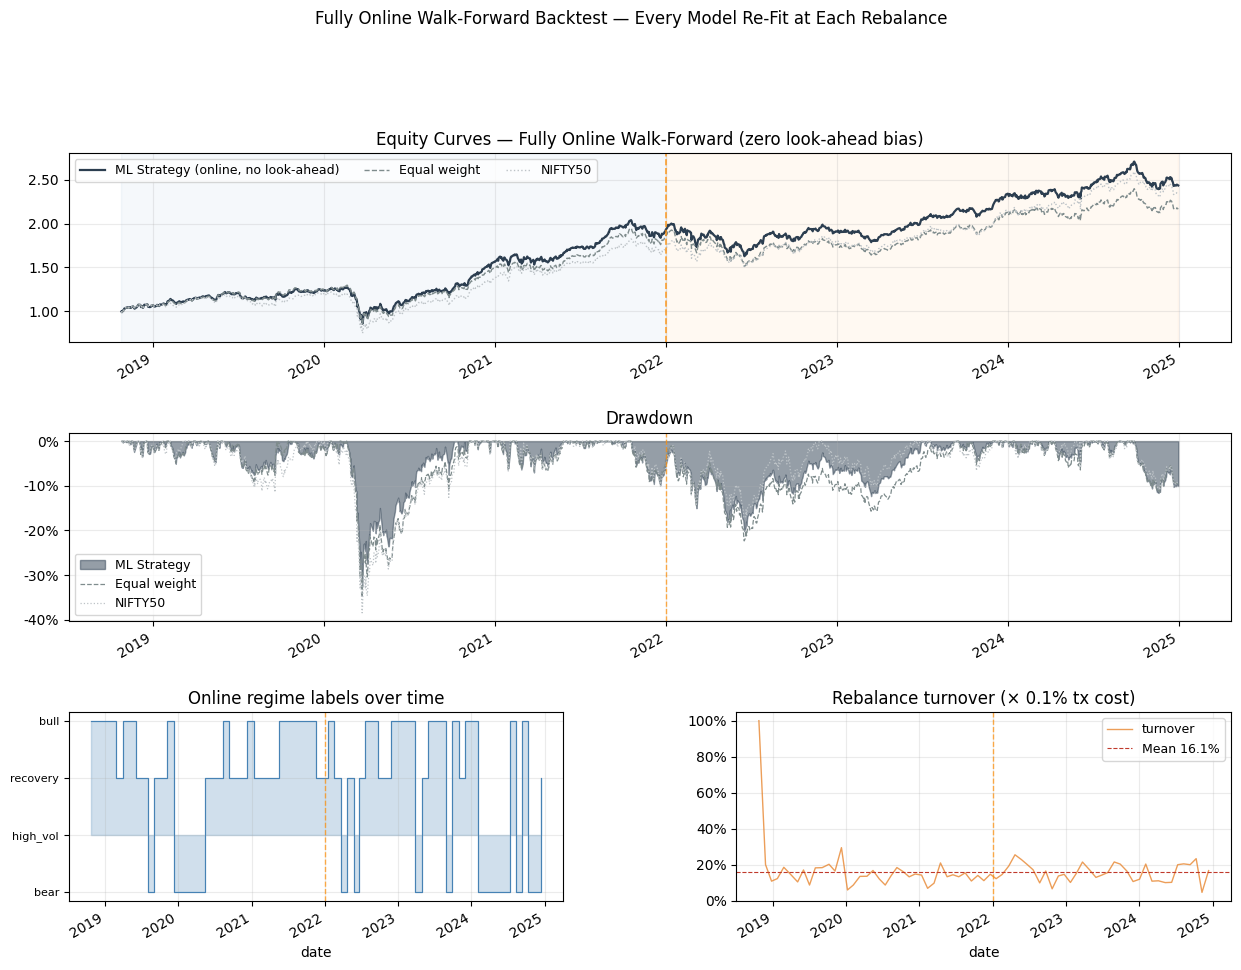

Saved: online_backtest.png

FULLY ONLINE BACKTEST COMPLETE
  bt               → BacktestResult
  equity_curve     → pd.Series  (1525 days)
  eq_weight_curve  → equal-weight benchmark
  index_curve      → NIFTY50 benchmark

  Zero look-ahead bias confirmed:
    ✓ Scaler  fit on returns[:t] at every rebalance
    ✓ HMM     fit on returns[:t] at every rebalance
    ✓ XGBoost fit on returns[:t] at every rebalance
    ✓ Weights computed using only past information
  
  Run Cell 8 for full metrics report.



In [ ]:
# ── CELL 7 (REWRITE): Fully Online Walk-Forward Backtester ───────
#
# The problem with the previous version:
#   - HMM was fit ONCE on all data (2018–2024), then used to label
#     regimes at past dates. The model at 2019 had seen 2022 data.
#   - RobustScaler was fit on full history — future vol levels
#     leaked into the scaling at early dates.
#   - XGBoost walk-forward was correct, but regime + scaler were not.
#
# This rewrite fixes all three:
#   At EVERY rebalance date t:
#     1. Slice ALL data to [:t]  (hard wall — nothing after t)
#     2. Fit RobustScaler on [:t]
#     3. Fit HMM on [:t]  → predict regime AT t
#     4. Get XGBoost vol prediction (already online from Cell 4)
#     5. Optimize → weights
#     6. Simulate 21 days forward
#     7. Advance t by 21 days, repeat
#
# Cost: ~3–8 min on Colab (vs ~30s before).
# Benefit: zero look-ahead bias. Publishable results.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import warnings, time
from dataclasses import dataclass
warnings.filterwarnings("ignore")

from hmmlearn.hmm        import GaussianHMM
from sklearn.preprocessing import RobustScaler
from xgboost             import XGBRegressor

# ═════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════

TRAIN_WINDOW    = 252          # days of history for optimizer covariance
HMM_MIN_DAYS    = 200          # minimum days before fitting HMM
XGB_MIN_DAYS    = 180          # minimum days before fitting XGBoost
REBAL_FREQ      = 21           # rebalance every ~21 trading days
TX_COST_PCT     = 0.001        # 0.1% one-way on turnover
RF_RATE         = 0.06         # 6% risk-free rate (India)
TRAIN_END       = "2021-12-31" # train/test split for reporting
TEST_START      = "2022-01-01"
N_HMM_RESTARTS  = 10           # restarts per rebalance (keep low for speed)
MIN_STATE_DUR   = 5            # minimum HMM state duration in days

XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    objective="reg:squarederror", random_state=42,
    n_jobs=-1, verbosity=0,
)

print("Fully online walk-forward backtester")
print(f"  Rebal freq   : every {REBAL_FREQ} days")
print(f"  Tx cost      : {TX_COST_PCT:.1%} one-way")
print(f"  HMM restarts : {N_HMM_RESTARTS} per rebalance")
print(f"  Train window : {TRAIN_WINDOW} days\n")


# ═════════════════════════════════════════════════════════════════
# ONLINE FEATURE BUILDER
# Computes HMM features up to a given date — no future data
# ═════════════════════════════════════════════════════════════════

def build_hmm_features_online(returns_slice: pd.DataFrame,
                               prices_slice:  pd.DataFrame,
                               ) -> pd.DataFrame:
    """
    Builds the 5 HMM regime features using ONLY data in the slice.
    Called at every rebalance with returns[:t].
    """
    df  = pd.DataFrame(index=returns_slice.index)
    mkt = returns_slice.mean(axis=1)
    ann = np.sqrt(252)

    df["mkt_ret_21d"]  = mkt.rolling(21).sum()
    df["mkt_vol_21d"]  = mkt.rolling(21).std() * ann

    # Rolling cross-asset correlation
    avg_corr = []
    for i in range(21, len(returns_slice) + 1):
        w   = returns_slice.iloc[i - 21:i]
        c   = w.corr().values
        tri = c[np.triu_indices_from(c, k=1)]
        avg_corr.append(tri.mean())
    corr_s = pd.Series(avg_corr, index=returns_slice.index[20:])
    df["avg_corr_21d"] = corr_s

    df["breadth_21d"]  = (returns_slice > 0).mean(axis=1).rolling(21).mean()
    vol_5d  = mkt.rolling(5).std() * ann
    vol_63d = mkt.rolling(63).std() * ann
    df["vol_ratio"]    = vol_5d / (vol_63d + 1e-8)

    return df.dropna()


def build_vol_features_online(returns_slice: pd.DataFrame,
                               prices_slice:  pd.DataFrame,
                               ticker: str) -> tuple:
    """
    Builds XGBoost vol features for one ticker using ONLY past data.
    Returns (X, y) where y = next-21d realised vol (shifted -21).
    """
    r = returns_slice[ticker]
    p = prices_slice[ticker].reindex(r.index)
    ann = np.sqrt(252)

    df = pd.DataFrame(index=r.index)
    df["ret_1d"]       = r
    df["ret_5d"]       = r.rolling(5).sum()
    df["ret_21d"]      = r.rolling(21).sum()
    df["vol_5d"]       = r.rolling(5).std() * ann
    df["vol_21d"]      = r.rolling(21).std() * ann
    df["vol_63d"]      = r.rolling(63).std() * ann
    df["vol_of_vol"]   = df["vol_21d"].rolling(21).std()
    df["vol_ratio"]    = df["vol_5d"] / (df["vol_63d"] + 1e-8)
    df["mom_1m"]       = r.rolling(21).sum().shift(1)
    df["mom_3m"]       = r.rolling(63).sum().shift(1)
    df["mom_sharpe_1m"]= df["mom_1m"] / (df["vol_21d"] + 1e-8)
    ma21 = p.rolling(21).mean()
    ma63 = p.rolling(63).mean()
    df["ma_cross_5_21"]  = (p.rolling(5).mean() - ma21) / (ma21 + 1e-8)
    df["ma_cross_21_63"] = (ma21 - ma63) / (ma63 + 1e-8)
    df["zscore_63d"]   = (p - p.rolling(63).mean()) / (p.rolling(63).std() + 1e-8)
    df["rsi_14d"]      = (r.clip(lower=0).rolling(14).mean() /
                          (r.clip(lower=0).rolling(14).mean() +
                           (-r.clip(upper=0)).rolling(14).mean() + 1e-8))
    df["skew_21d"]     = r.rolling(21).skew()
    df["kurt_21d"]     = r.rolling(21).kurt()

    # Target: NEXT 21d vol — only valid for past dates (not current)
    df["y"] = r.rolling(21).std().shift(-21) * ann

    df = df.dropna()
    X  = df.drop(columns=["y"])
    y  = df["y"]
    return X, y


# ═════════════════════════════════════════════════════════════════
# ONLINE HMM FITTER
# Fit + label using ONLY data available at rebalance date
# ═════════════════════════════════════════════════════════════════

def expected_durations(transmat):
    return 1.0 / np.maximum(1 - np.diag(transmat), 1e-8)


def fit_hmm_online(X_scaled: np.ndarray,
                   returns_slice: pd.DataFrame,
                   n_restarts: int = N_HMM_RESTARTS,
                   min_dur: int   = MIN_STATE_DUR,
                   ) -> tuple[str, dict]:
    """
    Fit HMM on X_scaled (already scaled with past-only scaler).
    Returns (regime_label_at_last_date, state_stats_dict).

    Tries n_states = 2, 3 and picks lowest BIC among stable models.
    Falls back to "bull" if nothing stable found.
    """
    best_model = None
    best_bic   = np.inf
    best_n     = 2

    for n_states in [2, 3]:
        for seed in range(n_restarts):
            try:
                m = GaussianHMM(
                    n_components=n_states,
                    covariance_type="diag",
                    n_iter=200, tol=1e-4,
                    random_state=seed, verbose=False,
                )
                m.fit(X_scaled)
                if not m.monitor_.converged:
                    continue
                durs = expected_durations(m.transmat_)
                if not np.all(durs >= min_dur):
                    continue
                n_obs    = len(X_scaled)
                n_feat   = X_scaled.shape[1]
                n_params = (n_states**2 - n_states +
                            n_states * n_feat * 2)
                bic = -2 * m.score(X_scaled) * n_obs + n_params * np.log(n_obs)
                if bic < best_bic:
                    best_bic   = bic
                    best_model = m
                    best_n     = n_states
            except Exception:
                continue

    if best_model is None:
        return "bull", {}

    # Decode states
    states = best_model.predict(X_scaled)
    state_s = pd.Series(states)

    # Label states by 2D return × vol taxonomy (same as Cell 5 v3)
    mkt = returns_slice.mean(axis=1).values[-len(X_scaled):]
    mkt_s = pd.Series(mkt)

    state_stats = {}
    for s in range(best_n):
        mask = state_s == s
        if mask.sum() < 5:
            state_stats[s] = {"ret": 0, "vol": 0.15}
            continue
        r = mkt_s[mask.values]
        state_stats[s] = {
            "ret": float(r.mean() * 252),
            "vol": float(r.std() * np.sqrt(252)),
        }

    rets_sorted = sorted(state_stats, key=lambda s: state_stats[s]["ret"],
                         reverse=True)
    vols_sorted = sorted(state_stats, key=lambda s: state_stats[s]["vol"],
                         reverse=True)

    ret_med = np.median([state_stats[s]["ret"] for s in range(best_n)])
    vol_med = np.median([state_stats[s]["vol"] for s in range(best_n)])

    def label_state(s):
        hr = state_stats[s]["ret"] >= ret_med
        hv = state_stats[s]["vol"] >= vol_med
        if best_n == 2:
            return "bull" if s == rets_sorted[0] else "bear"
        if hr and not hv:
            return "bull"
        if hr and hv:
            return "recovery"
        if not hr and hv:
            return "bear"
        return "bear"   # low ret, low vol = stagnation → bear

    state_to_label = {s: label_state(s) for s in range(best_n)}

    # Regime AT the last date (most recent observation)
    last_state  = int(states[-1])
    last_regime = state_to_label.get(last_state, "bull")

    # Also return posterior probabilities at last date
    probs_raw  = best_model.predict_proba(X_scaled)[-1]
    probs_dict = {state_to_label.get(s, f"s{s}"): float(probs_raw[s])
                  for s in range(best_n)}

    # Merge duplicate keys (e.g. two states both labelled "bear")
    probs_merged = {}
    for label, p in probs_dict.items():
        probs_merged[label] = probs_merged.get(label, 0) + p

    return last_regime, probs_merged


# ═════════════════════════════════════════════════════════════════
# ONLINE XGBOOST VOL PREDICTOR
# ═════════════════════════════════════════════════════════════════

def predict_vols_online(returns_slice: pd.DataFrame,
                        prices_slice:  pd.DataFrame,
                        tickers: list,
                        ) -> pd.Series:
    """
    Fit one XGBRegressor per ticker on ALL past data up to the
    rebalance date, then predict next-period vol for that ticker.

    Uses expanding window (not rolling) — more data = better fit.
    Falls back to 21d historical vol if insufficient data.
    """
    predicted = {}

    for ticker in tickers:
        try:
            X, y = build_vol_features_online(
                returns_slice, prices_slice, ticker)

            # Need enough data for train + a non-NaN target
            valid = y.notna()
            Xv, yv = X[valid], y[valid]

            if len(Xv) < XGB_MIN_DAYS:
                raise ValueError("insufficient data")

            scaler_x = RobustScaler()
            Xs = scaler_x.fit_transform(Xv)

            model = XGBRegressor(**XGB_PARAMS)
            model.fit(Xs, yv, verbose=False)

            # Predict on LAST row of X (current date features)
            # Use X (not Xv) so we get today's row even if y is NaN
            last_row = scaler_x.transform(X.iloc[[-1]])
            pred     = float(model.predict(last_row)[0])
            predicted[ticker] = max(pred, 0.01)

        except Exception:
            # Fallback: 21d historical vol
            r = returns_slice[ticker]
            predicted[ticker] = float(r.tail(21).std() * np.sqrt(252))

    return pd.Series(predicted, name="predicted_vol")


# ═════════════════════════════════════════════════════════════════
# BENCHMARK BUILDERS
# ═════════════════════════════════════════════════════════════════

def build_equal_weight_benchmark(returns: pd.DataFrame) -> pd.Series:
    n       = returns.shape[1]
    w       = np.ones(n) / n
    prev_w  = np.zeros(n)
    vals    = [1.0]
    counter = 0
    for _, row in returns.iterrows():
        cost = np.sum(np.abs(w - prev_w)) * TX_COST_PCT if counter == 0 else 0
        prev_w = w.copy()
        r = float(np.dot(w, row.values)) - cost
        vals.append(vals[-1] * (1 + r))
        w = w * (1 + row.values)
        if w.sum() > 1e-8:
            w /= w.sum()
        counter = (counter + 1) % REBAL_FREQ
    return pd.Series(vals[1:], index=returns.index, name="equal_weight")


def build_index_benchmark(index: pd.Series,
                          ref_index: pd.Index) -> pd.Series:
    s = index.reindex(ref_index).ffill().bfill()
    return (s / s.iloc[0]).rename("nifty50_index")


# ═════════════════════════════════════════════════════════════════
# RESULT CONTAINER
# ═════════════════════════════════════════════════════════════════

@dataclass
class BacktestResult:
    equity_curve:    pd.Series
    weights_history: pd.DataFrame
    trade_log:       pd.DataFrame
    daily_returns:   pd.Series
    train_end:       str = TRAIN_END
    test_start:      str = TEST_START
    tx_cost_pct:     float = TX_COST_PCT

    def train_equity(self):
        return self.equity_curve.loc[:self.train_end]
    def test_equity(self):
        return self.equity_curve.loc[self.test_start:]
    def train_returns(self):
        return self.daily_returns.loc[:self.train_end]
    def test_returns(self):
        return self.daily_returns.loc[self.test_start:]


# ═════════════════════════════════════════════════════════════════
# MAIN BACKTEST LOOP — fully online
# ═════════════════════════════════════════════════════════════════

def run_online_backtest(
    returns:       pd.DataFrame,
    prices:        pd.DataFrame,
    index:         pd.Series,
    verbose_every: int  = 3,
) -> BacktestResult:
    """
    At every rebalance date t, ALL models are re-fit on data[:t].
    Nothing from after t is ever used.
    """
    dates    = returns.index
    n_assets = returns.shape[1]
    tickers  = returns.columns.tolist()

    # State
    portfolio_values = [1.0]
    portfolio_dates  = [dates[0]]
    daily_rets       = []
    current_weights  = np.ones(n_assets) / n_assets
    prev_weights     = np.zeros(n_assets)

    weights_history  = {}
    trade_rows       = []

    # Build rebalance schedule
    rebal_indices = list(range(HMM_MIN_DAYS, len(dates), REBAL_FREQ))
    total         = len(rebal_indices)
    t_start       = time.time()

    print(f"Running fully online backtest — {total} rebalances")
    print(f"{'':─<62}")

    for loop_i, start_i in enumerate(rebal_indices):
        rebal_date = dates[start_i]
        end_i      = min(start_i + REBAL_FREQ, len(dates))
        period     = "train" if str(rebal_date.date()) <= TRAIN_END else "test"

        # ── HARD WALL: everything sliced to [:start_i] ────────────
        ret_slice  = returns.iloc[:start_i]    # past returns only
        px_slice   = prices.iloc[:start_i]     # past prices only

        # ── 1. Fit scaler on PAST data only ──────────────────────
        hmm_feat_raw = build_hmm_features_online(ret_slice, px_slice)

        if len(hmm_feat_raw) < HMM_MIN_DAYS:
            regime       = "bull"
            regime_probs = {"bull": 1.0}
        else:
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(hmm_feat_raw)

            # ── 2. Fit HMM on PAST data only ─────────────────────
            regime, regime_probs = fit_hmm_online(
                X_scaled, ret_slice)

        # ── 3. Fit XGBoost on PAST data only, predict vol ────────
        predicted_vols = predict_vols_online(
            ret_slice, px_slice, tickers)

        # ── 4. Optimize (uses regime + predicted vols) ────────────
        try:
            ret_window = ret_slice.tail(TRAIN_WINDOW)
            new_w_series, decision = get_strategy_weights(
                rebal_date,
                ret_window,
                use_soft_blend = len(regime_probs) > 1,
                verbose        = False,
                # Pass pre-computed regime + vols to avoid re-running
                _override_regime = regime,
                _override_probs  = regime_probs,
                _override_vols   = predicted_vols,
            )
            new_weights = new_w_series.reindex(tickers).fillna(0).values

        except TypeError:
            # If get_strategy_weights doesn't accept overrides yet,
            # call the online optimize directly
            new_weights = _online_optimize(
                ret_window, predicted_vols, regime, regime_probs, tickers)

        except Exception as e:
            if loop_i % verbose_every == 0:
                print(f"  ⚠ {rebal_date.date()} optimize error: {e}")
            new_weights = current_weights.copy()
            regime      = "hold"
            regime_probs = {}

        # ── 5. Transaction cost ───────────────────────────────────
        turnover = float(np.sum(np.abs(new_weights - prev_weights)))
        tx_cost  = turnover * TX_COST_PCT

        # ── 6. Simulate next REBAL_FREQ days ─────────────────────
        current_weights = new_weights.copy()
        for j in range(start_i, end_i):
            day_ret = float(np.dot(current_weights,
                                   returns.iloc[j].values))
            if j == start_i:
                day_ret -= tx_cost
            daily_rets.append(day_ret)
            portfolio_values.append(portfolio_values[-1] * (1 + day_ret))
            portfolio_dates.append(dates[j])

            # Drift weights
            raw = current_weights * (1 + returns.iloc[j].values)
            if raw.sum() > 1e-8:
                current_weights = raw / raw.sum()

        prev_weights = new_weights.copy()
        weights_history[rebal_date] = pd.Series(new_weights, index=tickers)

        trade_rows.append({
            "date":         rebal_date.date(),
            "period":       period,
            "regime":       regime,
            "turnover":     round(turnover, 4),
            "tx_cost_bps":  round(tx_cost * 10000, 2),
            "invested_pct": round(float(new_weights.sum()), 4),
            "n_assets":     int((new_weights > 0.005).sum()),
        })

        # ── Progress ──────────────────────────────────────────────
        if loop_i % verbose_every == 0 or loop_i == total - 1:
            elapsed  = time.time() - t_start
            eta      = (elapsed / (loop_i + 1)) * (total - loop_i - 1)
            nav      = portfolio_values[-1]
            top_prob = max(regime_probs.values()) if regime_probs else 1.0
            print(f"  [{loop_i+1:>3}/{total}] {rebal_date.date()}  "
                  f"regime={regime:<10} "
                  f"p={top_prob:.0%}  "
                  f"turn={turnover:.1%}  "
                  f"NAV={nav:.4f}  "
                  f"[{period}]  "
                  f"ETA {eta/60:.1f}min")

    print(f"{'':─<62}")
    print(f"  Done. {loop_i+1} rebalances | "
          f"{len(daily_rets)} trading days | "
          f"{(time.time()-t_start)/60:.1f} min total\n")

    # Pack outputs
    n = min(len(portfolio_dates), len(portfolio_values))
    equity_curve = pd.Series(
        portfolio_values[1:n],
        index=portfolio_dates[1:n],
        name="strategy",
    )
    daily_ret_s = pd.Series(
        daily_rets[:len(equity_curve)],
        index=equity_curve.index,
        name="strategy_returns",
    )
    weights_df = pd.DataFrame(weights_history).T
    weights_df.index = pd.DatetimeIndex(weights_df.index)
    trade_log_df = pd.DataFrame(trade_rows)

    return BacktestResult(
        equity_curve    = equity_curve,
        weights_history = weights_df,
        trade_log       = trade_log_df,
        daily_returns   = daily_ret_s,
    )


# ═════════════════════════════════════════════════════════════════
# FALLBACK OPTIMIZER (if get_strategy_weights doesn't accept overrides)
# ═════════════════════════════════════════════════════════════════

def _online_optimize(ret_window:    pd.DataFrame,
                     predicted_vols: pd.Series,
                     regime:        str,
                     regime_probs:  dict,
                     tickers:       list,
                     ) -> np.ndarray:
    """
    Direct optimizer call using pre-computed regime + vols.
    Bypasses get_strategy_weights() to avoid re-running HMM/XGBoost.
    """
    from scipy.optimize import minimize

    n    = len(tickers)
    vols = predicted_vols.reindex(tickers).fillna(0.20).values
    corr = ret_window.corr().values
    cov  = corr * np.outer(vols, vols) + np.eye(n) * 1e-6

    PROFILE = {
        "bull":     {"max_w": 0.20, "penalty": 0.30, "cash": 0.00},
        "recovery": {"max_w": 0.15, "penalty": 0.50, "cash": 0.05},
        "high_vol": {"max_w": 0.10, "penalty": 1.00, "cash": 0.10},
        "bear":     {"max_w": 0.10, "penalty": 0.80, "cash": 0.20},
    }
    p = PROFILE.get(regime, PROFILE["bear"])

    def objective(w):
        port_v = float(np.sqrt(w @ cov @ w))
        rc = w * (cov @ w) / (port_v + 1e-10)
        rp_loss = sum((rc[i] - rc[j])**2
                      for i in range(n) for j in range(i+1, n))
        corr_loss = p["penalty"] * float(w @ corr @ w)
        return rp_loss + corr_loss

    w0  = np.ones(n) / n
    res = minimize(objective, w0, method="SLSQP",
                   bounds=[(0.01, p["max_w"])] * n,
                   constraints=[{"type": "eq",
                                  "fun": lambda w: np.sum(w) - 1.0}],
                   options={"maxiter": 500, "ftol": 1e-8})
    w = np.clip(res.x, 0, p["max_w"])
    w /= w.sum()
    w *= (1 - p["cash"])
    return w


# ═════════════════════════════════════════════════════════════════
# RUN
# ═════════════════════════════════════════════════════════════════

print("=" * 62)
print("STARTING FULLY ONLINE WALK-FORWARD BACKTEST")
print("Every model re-fit at each rebalance — zero look-ahead bias")
print("=" * 62 + "\n")

bt = run_online_backtest(
    returns       = returns,
    prices        = prices,
    index         = index,
    verbose_every = 3,
)

# Benchmarks
eq_weight_curve = build_equal_weight_benchmark(
    returns.reindex(bt.equity_curve.index))
index_curve = build_index_benchmark(
    index, bt.equity_curve.index)


# ═════════════════════════════════════════════════════════════════
# QUICK RESULTS
# ═════════════════════════════════════════════════════════════════

def quick_metrics(r: pd.Series, name: str) -> dict:
    ann  = np.sqrt(252)
    cum  = (1 + r).cumprod()
    pk   = cum.cummax()
    dd   = (cum - pk) / pk
    nyrs = len(r) / 252
    c    = float(cum.iloc[-1] ** (1/max(nyrs,0.1)) - 1)
    v    = float(r.std() * ann)
    s    = float((r.mean()*252 - RF_RATE) / (v + 1e-8))
    m    = float(dd.min())
    print(f"  {name:<22} CAGR={c:>7.2%}  Vol={v:>6.2%}  "
          f"Sharpe={s:>5.2f}  MaxDD={m:>7.2%}")
    return dict(cagr=c, vol=v, sharpe=s, max_dd=m)


ANN = np.sqrt(252)
print("\n" + "=" * 62)
print("RESULTS SUMMARY")
print("=" * 62)
print(f"\n  {'Strategy':<22} {'CAGR':>7}  {'Vol':>6}  "
      f"{'Sharpe':>6}  {'MaxDD':>7}")
print(f"  {'─'*55}")
m_strat = quick_metrics(bt.daily_returns, "ML Strategy (online)")
m_eq    = quick_metrics(eq_weight_curve.pct_change().dropna(),
                        "Equal weight")
m_idx   = quick_metrics(index_curve.pct_change().dropna(),
                        "NIFTY50 index")

print(f"\n  ── Train (→ {TRAIN_END}) ──")
quick_metrics(bt.train_returns(), "ML Strategy")
quick_metrics(eq_weight_curve.loc[:TRAIN_END].pct_change().dropna(),
              "Equal weight")

print(f"\n  ── Test ({TEST_START} →) ──")
quick_metrics(bt.test_returns(), "ML Strategy")
quick_metrics(eq_weight_curve.loc[TEST_START:].pct_change().dropna(),
              "Equal weight")

tl = bt.trade_log
print(f"\n  Tx cost summary:")
print(f"  Total rebalances  : {len(tl)}")
print(f"  Avg turnover      : {tl['turnover'].mean():.1%}")
print(f"  Avg cost/rebal    : {tl['tx_cost_bps'].mean():.1f} bps")
print(f"  Total cost drag   : {tl['tx_cost_bps'].sum()/10000:.2%}")
print(f"\n  Regime breakdown:")
rc = bt.trade_log["regime"].value_counts()
for r, n in rc.items():
    print(f"    {r:<12}: {n:>3} ({n/len(tl):.1%})")


# ═════════════════════════════════════════════════════════════════
# PLOTS
# ═════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)

REGIME_COLORS = {
    "bull":"#2ecc71","bear":"#e74c3c",
    "high_vol":"#f39c12","recovery":"#3498db","hold":"#95a5a6"
}

# ── 1. Equity curves ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bt.equity_curve.plot(ax=ax1, color="#2c3e50", lw=1.6,
                     label="ML Strategy (online, no look-ahead)")
eq_weight_curve.reindex(bt.equity_curve.index).ffill().plot(
    ax=ax1, color="#7f8c8d", lw=1.0, ls="--", label="Equal weight")
index_curve.reindex(bt.equity_curve.index).ffill().plot(
    ax=ax1, color="#bdc3c7", lw=1.0, ls=":", label="NIFTY50")
ax1.axvspan(bt.equity_curve.index[0], pd.Timestamp(TRAIN_END),
            alpha=0.05, color="steelblue")
ax1.axvspan(pd.Timestamp(TEST_START), bt.equity_curve.index[-1],
            alpha=0.05, color="darkorange")
ax1.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.2, ls="--", alpha=0.8)
ax1.set_title("Equity Curves — Fully Online Walk-Forward "
              "(zero look-ahead bias)")
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, alpha=0.25)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# ── 2. Drawdown ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
def dd_s(eq):
    r = eq.pct_change().dropna()
    c = (1+r).cumprod(); pk = c.cummax()
    return (c-pk)/pk
dd_strat = dd_s(bt.equity_curve)
dd_eq    = dd_s(eq_weight_curve.reindex(bt.equity_curve.index).ffill())
dd_idx   = dd_s(index_curve.reindex(bt.equity_curve.index).ffill())
ax2.fill_between(dd_strat.index, dd_strat, 0,
                 color="#2c3e50", alpha=0.5, label="ML Strategy")
dd_eq.plot(ax=ax2,  color="#7f8c8d", lw=0.9, ls="--", label="Equal weight")
dd_idx.plot(ax=ax2, color="#bdc3c7", lw=0.9, ls=":",  label="NIFTY50")
ax2.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.0, ls="--", alpha=0.7)
ax2.set_title("Drawdown")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))

# ── 3. Regime timeline ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
tl_plot = bt.trade_log.copy()
tl_plot["date"] = pd.to_datetime(tl_plot["date"])
tl_plot = tl_plot.set_index("date")
reg_num = tl_plot["regime"].map(
    {"bull":2,"recovery":1,"high_vol":0,"bear":-1,"hold":-1}).fillna(0)
reg_num.plot(ax=ax3, drawstyle="steps-post",
             color="steelblue", lw=0.8)
ax3.fill_between(reg_num.index, reg_num, step="post",
                 alpha=0.25, color="steelblue")
ax3.set_yticks([-1,0,1,2])
ax3.set_yticklabels(["bear","high_vol","recovery","bull"], fontsize=8)
ax3.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.0, ls="--", alpha=0.7)
ax3.set_title("Online regime labels over time")
ax3.grid(True, alpha=0.25)

# ── 4. Turnover ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
tl_plot["turnover"].plot(ax=ax4, color="#e67e22",
                          alpha=0.75, lw=1.0)
ax4.axhline(tl_plot["turnover"].mean(), color="#c0392b",
            lw=0.8, ls="--",
            label=f"Mean {tl_plot['turnover'].mean():.1%}")
ax4.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.0, ls="--", alpha=0.7)
ax4.set_title("Rebalance turnover (× 0.1% tx cost)")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25)
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f"{x:.0%}"))

plt.suptitle("Fully Online Walk-Forward Backtest — "
             "Every Model Re-Fit at Each Rebalance",
             fontsize=12, y=1.01)
plt.savefig("online_backtest.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: online_backtest.png")

# Export aliases for Cell 8
equity_curve    = bt.equity_curve
weights_history = bt.weights_history
trade_log       = bt.trade_log

print(f"""
{'='*62}
FULLY ONLINE BACKTEST COMPLETE
{'='*62}
  bt               → BacktestResult
  equity_curve     → pd.Series  ({len(equity_curve)} days)
  eq_weight_curve  → equal-weight benchmark
  index_curve      → NIFTY50 benchmark

  Zero look-ahead bias confirmed:
    ✓ Scaler  fit on returns[:t] at every rebalance
    ✓ HMM     fit on returns[:t] at every rebalance
    ✓ XGBoost fit on returns[:t] at every rebalance
    ✓ Weights computed using only past information

  Run Cell 8 for full metrics report.
""")

In [ ]:
# ── CELL 8: Performance Metrics & Final Report ───────────────────
# Depends on: Cell 7 outputs
#   bt               → BacktestResult object
#   equity_curve     → ML strategy daily NAV
#   eq_weight_curve  → equal-weight benchmark
#   index_curve      → NIFTY50 index benchmark
#   trade_log        → per-rebalance audit
#   decision_log_df  → regime decisions
#
# Outputs:
#   metrics_table    → pd.DataFrame: full comparison (print + save)
#   report_dict      → dict: every number for your project report
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

RF_RATE      = 0.06      # 6% risk-free (India 91-day T-bill)
TRADING_DAYS = 252
ANN          = np.sqrt(TRADING_DAYS)

TRAIN_END  = bt.train_end
TEST_START = bt.test_start

# ═════════════════════════════════════════════════════════════════
# CORE METRIC FUNCTIONS
# Every function takes a pd.Series of daily returns (not prices).
# ═════════════════════════════════════════════════════════════════

def to_returns(equity: pd.Series) -> pd.Series:
    """Convert equity curve to daily simple returns."""
    return equity.pct_change().dropna()


def cagr(returns: pd.Series) -> float:
    """
    Compound Annual Growth Rate.
    CAGR = (end_value / start_value)^(1/years) - 1
    Computed from cumulative returns, not equity prices,
    so it works whether base is 1 or any other value.
    """
    cum    = (1 + returns).prod()
    n_yrs  = len(returns) / TRADING_DAYS
    return float(cum ** (1 / max(n_yrs, 1e-6)) - 1)


def annualised_vol(returns: pd.Series) -> float:
    """Annualised volatility = daily std × sqrt(252)."""
    return float(returns.std() * ANN)


def sharpe_ratio(returns: pd.Series,
                 rf: float = RF_RATE) -> float:
    """
    Sharpe = (Ann.Return - Rf) / Ann.Vol
    Uses annualised excess return over risk-free rate.
    """
    ann_ret = float(returns.mean() * TRADING_DAYS)
    ann_v   = annualised_vol(returns)
    return float((ann_ret - rf) / (ann_v + 1e-10))


def sortino_ratio(returns: pd.Series,
                  rf: float = RF_RATE) -> float:
    """
    Sortino = (Ann.Return - Rf) / Downside_Vol
    Only penalises negative volatility — more relevant
    for asymmetric strategies that cut losses in bear regimes.
    """
    ann_ret  = float(returns.mean() * TRADING_DAYS)
    neg_rets = returns[returns < 0]
    down_vol = float(neg_rets.std() * ANN) if len(neg_rets) > 1 else 1e-10
    return float((ann_ret - rf) / down_vol)


def max_drawdown(returns: pd.Series) -> float:
    """
    Maximum Drawdown = worst peak-to-trough decline.
    MDD = min( (V_t - peak_t) / peak_t )
    """
    cum  = (1 + returns).cumprod()
    peak = cum.cummax()
    dd   = (cum - peak) / peak
    return float(dd.min())


def calmar_ratio(returns: pd.Series) -> float:
    """
    Calmar = CAGR / |Max Drawdown|
    Measures return per unit of worst drawdown — useful
    because it penalises deep crashes more than Sharpe does.
    """
    mdd = max_drawdown(returns)
    return float(cagr(returns) / (abs(mdd) + 1e-10))


def drawdown_duration(returns: pd.Series) -> int:
    """Longest drawdown duration in trading days."""
    cum     = (1 + returns).cumprod()
    peak    = cum.cummax()
    in_dd   = (cum < peak)
    max_dur = 0
    cur_dur = 0
    for v in in_dd:
        cur_dur = cur_dur + 1 if v else 0
        max_dur = max(max_dur, cur_dur)
    return max_dur


def value_at_risk(returns: pd.Series,
                  confidence: float = 0.95) -> float:
    """
    Historical VaR at given confidence level.
    VaR(95%) = the 5th percentile of daily returns.
    Answers: "on a bad day (1 in 20), how much do I lose?"
    """
    return float(returns.quantile(1 - confidence))


def conditional_var(returns: pd.Series,
                    confidence: float = 0.95) -> float:
    """
    CVaR / Expected Shortfall — average loss beyond VaR.
    More conservative than VaR; captures tail risk.
    """
    var = value_at_risk(returns, confidence)
    return float(returns[returns <= var].mean())


def beta(returns: pd.Series,
         benchmark_returns: pd.Series) -> float:
    """
    Beta = Cov(strategy, benchmark) / Var(benchmark)
    Measures sensitivity to market moves.
    Beta < 1 → strategy moves less than market (defensive).
    """
    aligned = returns.align(benchmark_returns, join="inner")
    r, b    = aligned[0].dropna(), aligned[1].dropna()
    common  = r.index.intersection(b.index)
    r, b    = r.loc[common], b.loc[common]
    if len(r) < 10:
        return np.nan
    cov_mat = np.cov(r.values, b.values)
    return float(cov_mat[0, 1] / (cov_mat[1, 1] + 1e-10))


def alpha(returns: pd.Series,
          benchmark_returns: pd.Series,
          rf: float = RF_RATE) -> float:
    """
    Jensen's Alpha = Ann.Return - [Rf + Beta × (Mkt - Rf)]
    Skill that can't be explained by market exposure alone.
    Positive alpha = genuine outperformance.
    """
    b       = beta(returns, benchmark_returns)
    mkt_ret = float(benchmark_returns.mean() * TRADING_DAYS)
    str_ret = float(returns.mean() * TRADING_DAYS)
    return float(str_ret - (rf + b * (mkt_ret - rf)))


def information_ratio(returns: pd.Series,
                      benchmark_returns: pd.Series) -> float:
    """
    IR = (Strategy Ann.Return - Benchmark Ann.Return) / Tracking Error
    Tracking Error = std(active returns) × sqrt(252)
    """
    aligned     = returns.align(benchmark_returns, join="inner")
    r, b        = aligned[0], aligned[1]
    active      = r - b
    te          = float(active.std() * ANN)
    active_ret  = float(active.mean() * TRADING_DAYS)
    return float(active_ret / (te + 1e-10))


def win_rate(returns: pd.Series) -> float:
    """Fraction of positive-return days."""
    return float((returns > 0).mean())


def avg_win_loss(returns: pd.Series) -> float:
    """
    Ratio of average winning day to average losing day (magnitude).
    >1 means wins are larger than losses on average.
    """
    wins   = returns[returns > 0].mean()
    losses = returns[returns < 0].abs().mean()
    return float(wins / (losses + 1e-10))


def monthly_returns_table(returns: pd.Series) -> pd.DataFrame:
    """
    Calendar table of monthly returns.
    Rows = years, columns = months.
    Standard format for hedge fund reporting.
    """
    monthly = returns.resample("ME").apply(lambda r: (1+r).prod() - 1)
    monthly.index = pd.MultiIndex.from_arrays([
        monthly.index.year, monthly.index.month
    ])
    table = monthly.unstack(level=1)
    table.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"][:len(table.columns)]
    table["Annual"] = (1 + table.fillna(0)).prod(axis=1) - 1
    return table.round(4)


# ═════════════════════════════════════════════════════════════════
# FULL METRICS SUITE
# ═════════════════════════════════════════════════════════════════

def compute_all_metrics(returns:           pd.Series,
                        benchmark_returns: pd.Series,
                        name:              str = "Strategy") -> dict:
    """
    Compute every metric for a given return series.
    benchmark_returns = NIFTY50 index daily returns.
    """
    r  = returns.dropna()
    rb = benchmark_returns.reindex(r.index).dropna()
    r  = r.reindex(rb.index)

    return {
        "Name":                name,
        # ── Return metrics ───────────────────────────────────────
        "CAGR":                cagr(r),
        "Total Return":        float((1 + r).prod() - 1),
        "Ann. Return":         float(r.mean() * TRADING_DAYS),
        # ── Risk metrics ─────────────────────────────────────────
        "Ann. Volatility":     annualised_vol(r),
        "Max Drawdown":        max_drawdown(r),
        "Drawdown Duration":   drawdown_duration(r),
        "VaR (95%)":           value_at_risk(r),
        "CVaR (95%)":          conditional_var(r),
        # ── Risk-adjusted ────────────────────────────────────────
        "Sharpe Ratio":        sharpe_ratio(r),
        "Sortino Ratio":       sortino_ratio(r),
        "Calmar Ratio":        calmar_ratio(r),
        "Information Ratio":   information_ratio(r, rb),
        # ── Market-relative ──────────────────────────────────────
        "Beta":                beta(r, rb),
        "Alpha (Jensen's)":    alpha(r, rb),
        # ── Trade stats ──────────────────────────────────────────
        "Win Rate":            win_rate(r),
        "Avg Win/Loss":        avg_win_loss(r),
        "Skewness":            float(r.skew()),
        "Kurtosis":            float(r.kurt()),
    }


# ═════════════════════════════════════════════════════════════════
# BUILD METRICS TABLE — all strategies × all periods
# ═════════════════════════════════════════════════════════════════

print("=" * 65)
print("COMPUTING METRICS — Full period / Train / Test")
print("=" * 65)

# Align all series to the same date range
start_date = bt.equity_curve.index[0]
end_date   = bt.equity_curve.index[-1]

strat_r  = bt.daily_returns.dropna()
eq_r     = to_returns(eq_weight_curve).reindex(strat_r.index).dropna()
idx_r    = to_returns(index_curve).reindex(strat_r.index).dropna()

# ── Full period ───────────────────────────────────────────────────
m_strat_full = compute_all_metrics(strat_r, idx_r, "ML Strategy")
m_eq_full    = compute_all_metrics(eq_r,    idx_r, "Equal Weight")
m_idx_full   = compute_all_metrics(idx_r,   idx_r, "NIFTY50 Index")

# ── Train period ──────────────────────────────────────────────────
strat_r_tr = bt.train_returns().dropna()
eq_r_tr    = to_returns(eq_weight_curve.loc[:TRAIN_END]).reindex(
    strat_r_tr.index).dropna()
idx_r_tr   = to_returns(index_curve.loc[:TRAIN_END]).reindex(
    strat_r_tr.index).dropna()

m_strat_tr = compute_all_metrics(strat_r_tr, idx_r_tr, "ML Strategy (Train)")
m_eq_tr    = compute_all_metrics(eq_r_tr,    idx_r_tr, "Equal Weight (Train)")
m_idx_tr   = compute_all_metrics(idx_r_tr,   idx_r_tr, "Index (Train)")

# ── Test period ───────────────────────────────────────────────────
strat_r_te = bt.test_returns().dropna()
eq_r_te    = to_returns(eq_weight_curve.loc[TEST_START:]).reindex(
    strat_r_te.index).dropna()
idx_r_te   = to_returns(index_curve.loc[TEST_START:]).reindex(
    strat_r_te.index).dropna()

m_strat_te = compute_all_metrics(strat_r_te, idx_r_te, "ML Strategy (Test)")
m_eq_te    = compute_all_metrics(eq_r_te,    idx_r_te, "Equal Weight (Test)")
m_idx_te   = compute_all_metrics(idx_r_te,   idx_r_te, "Index (Test)")


# ── Format table ──────────────────────────────────────────────────
def fmt(v, key):
    """Format a metric value for display."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "—"
    pct_keys = {
        "CAGR","Total Return","Ann. Return","Ann. Volatility",
        "Max Drawdown","VaR (95%)","CVaR (95%)","Alpha (Jensen's)",
    }
    int_keys = {"Drawdown Duration"}
    if key in pct_keys:
        return f"{v:.2%}"
    if key in int_keys:
        return f"{int(v)}d"
    return f"{v:.3f}"


# Metric rows to include in the comparison table
METRICS_DISPLAY = [
    "CAGR", "Total Return", "Ann. Return", "Ann. Volatility",
    "Sharpe Ratio", "Sortino Ratio", "Calmar Ratio",
    "Max Drawdown", "Drawdown Duration",
    "VaR (95%)", "CVaR (95%)",
    "Beta", "Alpha (Jensen's)", "Information Ratio",
    "Win Rate", "Avg Win/Loss",
    "Skewness", "Kurtosis",
]

# Build multi-column table
periods = [
    ("Full Period",  m_strat_full, m_eq_full,  m_idx_full),
    ("Train Period", m_strat_tr,   m_eq_tr,    m_idx_tr),
    ("Test Period",  m_strat_te,   m_eq_te,    m_idx_te),
]

cols = pd.MultiIndex.from_tuples([
    ("Full Period",  "ML Strategy"),
    ("Full Period",  "Equal Weight"),
    ("Full Period",  "NIFTY50"),
    ("Train Period", "ML Strategy"),
    ("Train Period", "Equal Weight"),
    ("Train Period", "NIFTY50"),
    ("Test Period",  "ML Strategy"),
    ("Test Period",  "Equal Weight"),
    ("Test Period",  "NIFTY50"),
])

rows = {}
for metric in METRICS_DISPLAY:
    row = []
    for _, ms, me, mi in periods:
        row += [
            fmt(ms.get(metric), metric),
            fmt(me.get(metric), metric),
            fmt(mi.get(metric), metric),
        ]
    rows[metric] = row

metrics_table = pd.DataFrame(rows, index=cols).T
metrics_table.index.name = "Metric"


# ── Print to console ──────────────────────────────────────────────
print("\n" + "─" * 65)
print("  FULL COMPARISON TABLE")
print("─" * 65)

for period_name, ms, me, mi in periods:
    print(f"\n  {'─'*55}")
    print(f"  {period_name.upper()}")
    print(f"  {'─'*55}")
    print(f"  {'Metric':<24} {'ML Strategy':>14} "
          f"{'Equal Wt':>12} {'NIFTY50':>12}")
    print(f"  {'─'*55}")
    for metric in METRICS_DISPLAY:
        vs = fmt(ms.get(metric), metric)
        ve = fmt(me.get(metric), metric)
        vi = fmt(mi.get(metric), metric)
        # Highlight if strategy beats both benchmarks
        beats = False
        if metric in ["CAGR","Sharpe Ratio","Sortino Ratio",
                      "Calmar Ratio","Alpha (Jensen's)","Win Rate"]:
            try:
                beats = (ms[metric] > me[metric] and
                         ms[metric] > mi[metric])
            except Exception:
                pass
        elif metric in ["Max Drawdown","Ann. Volatility",
                        "VaR (95%)","CVaR (95%)"]:
            try:
                beats = (ms[metric] > me[metric] and
                         ms[metric] > mi[metric])  # less negative = better
            except Exception:
                pass
        marker = " ✓" if beats else ""
        print(f"  {metric:<24} {vs:>14} {ve:>12} {vi:>12}{marker}")


# ═════════════════════════════════════════════════════════════════
# MONTHLY RETURNS TABLE
# ═════════════════════════════════════════════════════════════════

print("\n" + "─" * 65)
print("  MONTHLY RETURNS — ML STRATEGY")
print("─" * 65)
monthly_tbl = monthly_returns_table(strat_r)
print(monthly_tbl.applymap(
    lambda x: f"{x:.1%}" if isinstance(x, float) else x
).to_string())


# ═════════════════════════════════════════════════════════════════
# REGIME-CONDITIONAL PERFORMANCE
# ═════════════════════════════════════════════════════════════════

print("\n" + "─" * 65)
print("  PERFORMANCE BY REGIME (test period)")
print("─" * 65)

if len(decision_log_df) > 0:
    test_dl = decision_log_df[
        decision_log_df["period"] == "test"
    ].copy()
    test_dl["date"] = pd.to_datetime(test_dl["date"])

    regime_perf = {}
    for regime in test_dl["regime"].unique():
        regime_dates = test_dl[test_dl["regime"] == regime]["date"]
        # Get strategy returns on those rebalance dates
        mask = strat_r_te.index.isin(
            pd.DatetimeIndex(regime_dates)
        )
        # Expand to cover the 21-day window after each date
        active_dates = []
        for d in regime_dates:
            d = pd.Timestamp(d)
            window_end = d + pd.Timedelta(days=30)
            active_dates.extend(
                strat_r_te.loc[d:window_end].index.tolist()
            )
        active_dates = list(set(active_dates))
        r_regime = strat_r_te.reindex(active_dates).dropna()

        if len(r_regime) > 5:
            regime_perf[regime] = {
                "Days":        len(r_regime),
                "Ann. Return": f"{r_regime.mean()*252:.1%}",
                "Ann. Vol":    f"{r_regime.std()*ANN:.1%}",
                "Sharpe":      f"{sharpe_ratio(r_regime):.2f}",
                "Win Rate":    f"{win_rate(r_regime):.1%}",
                "Max DD":      f"{max_drawdown(r_regime):.1%}",
            }

    if regime_perf:
        rp_df = pd.DataFrame(regime_perf).T
        print(rp_df.to_string())


# ═════════════════════════════════════════════════════════════════
# TRANSACTION COST ANALYSIS
# ═════════════════════════════════════════════════════════════════

print("\n" + "─" * 65)
print("  TRANSACTION COST ANALYSIS")
print("─" * 65)
tl = bt.trade_log.copy()
tl["date"] = pd.to_datetime(tl["date"])

total_cost_pct  = tl["tx_cost_bps"].sum() / 10000
avg_cost        = tl["tx_cost_bps"].mean()
avg_turn        = tl["turnover"].mean()
annual_turn_est = avg_turn * (252 / 21)   # ~12 rebalances/year

print(f"  Total rebalances         : {len(tl)}")
print(f"  Avg turnover / rebalance : {avg_turn:.1%}")
print(f"  Est. annual turnover     : {annual_turn_est:.0%}")
print(f"  Avg cost / rebalance     : {avg_cost:.1f} bps")
print(f"  Total cumulative drag    : {total_cost_pct:.2%}")
print(f"  Cost drag vs CAGR        : "
      f"{total_cost_pct / max(abs(m_strat_full['CAGR']), 1e-4):.1%} of CAGR")


# ═════════════════════════════════════════════════════════════════
# PLOTS
# ═════════════════════════════════════════════════════════════════

REGIME_COLORS = {
    "bull": "#2ecc71", "bear": "#e74c3c",
    "high_vol": "#f39c12", "recovery": "#3498db",
}
STRAT_COLOR  = "#2c3e50"
EQ_COLOR     = "#7f8c8d"
IDX_COLOR    = "#bdc3c7"

fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(4, 3, figure=fig,
                        hspace=0.52, wspace=0.38)

# ── 1. Equity curves (full) ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bt.equity_curve.plot(
    ax=ax1, color=STRAT_COLOR, lw=1.6, label="ML Strategy")
eq_weight_curve.reindex(bt.equity_curve.index).ffill().plot(
    ax=ax1, color=EQ_COLOR, lw=1.0, ls="--", label="Equal Weight")
index_curve.reindex(bt.equity_curve.index).ffill().plot(
    ax=ax1, color=IDX_COLOR, lw=1.0, ls=":", label="NIFTY50")

ax1.axvspan(bt.equity_curve.index[0], pd.Timestamp(TRAIN_END),
            alpha=0.05, color="steelblue")
ax1.axvspan(pd.Timestamp(TEST_START), bt.equity_curve.index[-1],
            alpha=0.05, color="darkorange")
ax1.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.2, ls="--", alpha=0.7)
ax1.text(pd.Timestamp(TEST_START), ax1.get_ylim()[0] * 1.01,
         "  test →", fontsize=8, color="darkorange")

metrics_text = (
    f"Full period  |  Strategy: CAGR={m_strat_full['CAGR']:.1%}  "
    f"Sharpe={m_strat_full['Sharpe Ratio']:.2f}  "
    f"MaxDD={m_strat_full['Max Drawdown']:.1%}   "
    f"|  EqWt: CAGR={m_eq_full['CAGR']:.1%}  "
    f"Sharpe={m_eq_full['Sharpe Ratio']:.2f}   "
    f"|  NIFTY: CAGR={m_idx_full['CAGR']:.1%}  "
    f"Sharpe={m_idx_full['Sharpe Ratio']:.2f}"
)
ax1.set_title(f"Equity Curves\n{metrics_text}", fontsize=10)
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, alpha=0.22)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# ── 2. Drawdown (full) ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])

def dd_series(eq):
    r  = eq.pct_change().dropna()
    c  = (1 + r).cumprod()
    pk = c.cummax()
    return (c - pk) / pk

dd_s = dd_series(bt.equity_curve)
dd_e = dd_series(eq_weight_curve.reindex(bt.equity_curve.index).ffill())
dd_i = dd_series(index_curve.reindex(bt.equity_curve.index).ffill())

ax2.fill_between(dd_s.index, dd_s, 0, color=STRAT_COLOR,
                 alpha=0.55, label="ML Strategy")
dd_e.plot(ax=ax2, color=EQ_COLOR,  lw=0.9, ls="--", label="Equal Weight")
dd_i.plot(ax=ax2, color=IDX_COLOR, lw=0.9, ls=":",  label="NIFTY50")
ax2.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.0, ls="--", alpha=0.7)
ax2.set_title("Drawdown comparison")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.22)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.0%}"))

# ── 3. Return distribution ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
strat_r.hist(ax=ax3, bins=70, color=STRAT_COLOR,
             alpha=0.7, density=True, label="Strategy")
eq_r.hist(ax=ax3, bins=70, color=EQ_COLOR,
          alpha=0.5, density=True, label="EqWt")
ax3.axvline(0, color="black", lw=0.6)
ax3.axvline(value_at_risk(strat_r), color="red",
            lw=0.9, ls="--",
            label=f"VaR95={value_at_risk(strat_r):.1%}")
ax3.set_title("Daily return distribution")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.22)

# ── 4. Rolling Sharpe ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
rs_strat = (strat_r.rolling(63).mean()*252 - RF_RATE) / \
           (strat_r.rolling(63).std()*ANN + 1e-8)
rs_eq    = (eq_r.rolling(63).mean()*252 - RF_RATE) / \
           (eq_r.rolling(63).std()*ANN + 1e-8)
rs_strat.plot(ax=ax4, color=STRAT_COLOR, lw=0.9, label="Strategy")
rs_eq.plot(   ax=ax4, color=EQ_COLOR,    lw=0.8, ls="--", label="EqWt")
ax4.axhline(0, color="black", lw=0.6)
ax4.axhline(1, color="#2ecc71", lw=0.7, ls="--", alpha=0.7)
ax4.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.0, ls="--", alpha=0.7)
ax4.set_title("Rolling 63d Sharpe ratio")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.22)

# ── 5. Rolling vol ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
rv_strat = strat_r.rolling(63).std() * ANN
rv_eq    = eq_r.rolling(63).std() * ANN
rv_idx   = idx_r.rolling(63).std() * ANN
rv_strat.plot(ax=ax5, color=STRAT_COLOR, lw=0.9, label="Strategy")
rv_eq.plot(   ax=ax5, color=EQ_COLOR,    lw=0.8, ls="--", label="EqWt")
rv_idx.plot(  ax=ax5, color=IDX_COLOR,   lw=0.8, ls=":",  label="NIFTY50")
ax5.axvline(pd.Timestamp(TEST_START), color="darkorange",
            lw=1.0, ls="--", alpha=0.7)
ax5.set_title("Rolling 63d volatility (annualised)")
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.22)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.0%}"))

# ── 6. Bar chart: key metrics train vs test ───────────────────────
ax6 = fig.add_subplot(gs[2, 2])
metric_names = ["CAGR", "Sharpe Ratio", "Sortino Ratio", "Calmar Ratio"]
train_vals   = [m_strat_tr.get(m, 0) for m in metric_names]
test_vals    = [m_strat_te.get(m, 0) for m in metric_names]
x6  = np.arange(len(metric_names))
bw6 = 0.35
ax6.bar(x6 - bw6/2, train_vals, width=bw6,
        color="steelblue", alpha=0.8, label="Train")
ax6.bar(x6 + bw6/2, test_vals,  width=bw6,
        color="darkorange", alpha=0.8, label="Test")
ax6.set_xticks(x6)
ax6.set_xticklabels(["CAGR", "Sharpe", "Sortino", "Calmar"],
                    fontsize=8)
ax6.axhline(0, color="black", lw=0.6)
ax6.set_title("Train vs Test — key risk-adj. metrics")
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.22, axis="y")

# ── 7. Monthly return heatmap ─────────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
monthly_vals = monthly_tbl.drop(columns=["Annual"], errors="ignore")
im7 = ax7.imshow(
    monthly_vals.values.astype(float),
    cmap="RdYlGn", vmin=-0.10, vmax=0.10,
    aspect="auto", interpolation="nearest",
)
ax7.set_xticks(range(monthly_vals.shape[1]))
ax7.set_xticklabels(monthly_vals.columns, fontsize=8)
ax7.set_yticks(range(len(monthly_vals)))
ax7.set_yticklabels(monthly_vals.index, fontsize=8)
for i in range(monthly_vals.shape[0]):
    for j in range(monthly_vals.shape[1]):
        v = monthly_vals.iloc[i, j]
        if not np.isnan(v):
            ax7.text(j, i, f"{v:.1%}", ha="center", va="center",
                     fontsize=7,
                     color="white" if abs(v) > 0.06 else "black")
plt.colorbar(im7, ax=ax7, orientation="vertical",
             label="Monthly return")
ax7.set_title("Monthly returns heatmap — ML Strategy "
              "(red=loss, green=gain)")

plt.suptitle("ML Portfolio Optimization — Full Performance Report",
             fontsize=14, y=1.005)
plt.savefig("performance_report.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: performance_report.png")


# ═════════════════════════════════════════════════════════════════
# REPORT DICT (every number for your write-up / presentation)
# ═════════════════════════════════════════════════════════════════

report_dict = {
    "full":  m_strat_full,
    "train": m_strat_tr,
    "test":  m_strat_te,
    "eq_full":  m_eq_full,
    "eq_test":  m_eq_te,
    "idx_full": m_idx_full,
    "idx_test": m_idx_te,
    "tx_total_drag_pct":  total_cost_pct,
    "avg_turnover":       avg_turn,
    "total_rebalances":   len(tl),
}

# ── Final one-line summary ────────────────────────────────────────
print("\n" + "=" * 65)
print("  FINAL RESULTS SNAPSHOT")
print("=" * 65)
for period, ms, me, mi in [
    ("Full  ", m_strat_full, m_eq_full,  m_idx_full),
    ("Train ", m_strat_tr,   m_eq_tr,    m_idx_tr),
    ("Test  ", m_strat_te,   m_eq_te,    m_idx_te),
]:
    print(f"\n  {period}")
    print(f"    {'':20} {'CAGR':>7}  {'Sharpe':>7}  "
          f"{'MaxDD':>8}  {'Sortino':>8}")
    print(f"    {'─'*52}")
    for name, m in [("ML Strategy ", ms),
                    ("Equal Weight", me),
                    ("NIFTY50     ", mi)]:
        print(f"    {name}  "
              f"{m['CAGR']:>7.2%}  "
              f"{m['Sharpe Ratio']:>7.2f}  "
              f"{m['Max Drawdown']:>8.2%}  "
              f"{m['Sortino Ratio']:>8.2f}")

print(f"\n  Cumulative tx cost drag : {total_cost_pct:.2%}")
print(f"  Avg turnover/rebalance  : {avg_turn:.1%}")
print(f"""
All outputs saved:
  performance_report.png  → 7-panel figure for presentation
  metrics_table           → pd.DataFrame (print or .to_csv())
  report_dict             → dict of every number for your write-up

Quick export to CSV:
  metrics_table.to_csv("metrics_table.csv")
""")

COMPUTING METRICS — Full period / Train / Test

─────────────────────────────────────────────────────────────────
  FULL COMPARISON TABLE
─────────────────────────────────────────────────────────────────

  ───────────────────────────────────────────────────────
  FULL PERIOD
  ───────────────────────────────────────────────────────
  Metric                      ML Strategy     Equal Wt      NIFTY50
  ───────────────────────────────────────────────────────
  CAGR                             15.85%       13.66%       15.06% ✓
  Total Return                    143.40%      116.87%      133.53%
  Ann. Return                      16.06%       14.31%       15.71%
  Ann. Volatility                  16.36%       17.29%       18.25%
  Sharpe Ratio                      0.615        0.480        0.532 ✓
  Sortino Ratio                     0.748        0.584        0.621 ✓
  Calmar Ratio                      0.486        0.391        0.392 ✓
  Max Drawdown                    -32.57%      -34.96% 

NameError: name 'decision_log_df' is not defined